# FIT5202 2026 S2 Assignment 1 : Analysing Parking & Congestion Patterns in Melbourne

## Table of Contents
* [Part 1 : Data Loading and Transformation](#part-1)  
    - [1.1 Data Preparation and Loading](#1.1)  
    - [1.2 Data Cleansing](#1.2)
    - [1.3 Partitition and Spark UI Evidence](#1.3)    
* [Part 2 : Working with DataFrames](#2-dataframes)  
    - [2.1-2.5 Query/Analysis](#2-dataframes)  
    - [2.6 Exploratory Analysis](#2.6)  
* [Part 3 : Query Optimisation](#part-3)  

Note: Feel free to add Code/Markdown cells as you need.

**Auth code:** student  


**AI acknowledgement:** OpenAI Codex was used to interpret the specification, develop code and explanatory text, troubleshoot execution, and assist with validation. Runtime outputs and timings are generated from the supplied
data.

# Part 1 : Data Loading and Transformation (10%) <a class="anchor" name="part-1"></a>
In this section, you need to create data frames from the given datasets, perform partitioning and use various operations to answer the queries.  

## 1.1 Data Preparation and Loading <a class="anchor" name="1.1"></a>
1. Configure the Spark session to run locally using four cores;
1. Assign an appropriate application name to the Spark session;
1. Set the session timezone explicitly to 'Australia/Melbourne';
1. Define and apply an explicit StructType schema when loading each CSV and JSON dataset. 
1. Print the schema and row count for each DataFrame;
1. Display the first five rows of each DataFrame to verify successful data loading.



In [ ]:
import os
import json
import time
import statistics
from pathlib import Path
from datetime import datetime, timezone
from urllib.request import urlopen

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from pyspark.sql import SparkSession, functions as F, types as T, Window
from pyspark import StorageLevel

student_auth_code = 'student'
DATA_DIR = Path(os.environ.get('A1_DATA_DIR', '/data'))
OUTPUT_DIR = Path(os.environ.get('A1_OUTPUT_DIR', '/work/output'))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EVIDENCE_DIR = OUTPUT_DIR / 'evidence'
EVIDENCE_DIR.mkdir(exist_ok=True)
TRAFFIC_MINUTE_ENCODING = 'block_index'  # Ten-minute block indices, supported by the teaching-team clarification.
os.environ['SPARK_LOCAL_DIRS'] = '/tmp/a1-spark'

spark = (SparkSession.builder.master('local[4]')
         .appName(f'FIT5202-A1-{student_auth_code}')
         .config('spark.sql.session.timeZone', 'Australia/Melbourne')
         .config('spark.driver.memory', '3g')
         .config('spark.sql.shuffle.partitions', '32')
         .config('spark.sql.adaptive.enabled', 'true')
         .config('spark.ui.retainedJobs', '2000')
         .config('spark.ui.retainedStages', '2000')
         .config('spark.sql.ui.retainedExecutions', '1000')
         .getOrCreate())
sc = spark.sparkContext
sc.setLogLevel('WARN')
print({'Spark': spark.version, 'master': sc.master,
       'timezone': spark.conf.get('spark.sql.session.timeZone'),
       'shuffle_partitions': spark.conf.get('spark.sql.shuffle.partitions'),
       'application_id': sc.applicationId, 'Spark_UI': sc.uiWebUrl})
assert spark.version.startswith('4.') and sc.master == 'local[4]'

def show_table(frame, n=20):
    frame.show(n, truncate=False)

def sum_flag(condition):
    return F.sum(F.when(condition, 1).otherwise(0)).cast('long')

def percentage(numerator, denominator):
    return F.when(denominator > 0, numerator.cast('double') / denominator * 100.0)

def evidence_snapshot(label):
    # Persist actual Spark REST metadata alongside the required visual screenshots.
    base = f'http://localhost:4040/api/v1/applications/{sc.applicationId}'
    result = {'label': label, 'applicationId': sc.applicationId,
              'captured_utc': datetime.now(timezone.utc).isoformat()}
    for endpoint in ('jobs', 'stages', 'sql'):
        try:
            with urlopen(f'{base}/{endpoint}', timeout=20) as response:
                result[endpoint] = json.load(response)
        except Exception as error:
            result[endpoint + '_error'] = str(error)
    (EVIDENCE_DIR / f'{label}.json').write_text(json.dumps(result, indent=2))
    return result

parking_columns = ['deviceid', 'arrivaltime', 'departuretime', 'streetmarker',
                   'signplateid', 'sign', 'streetid', 'betweenstreet1id',
                   'betweenstreet2id', 'sideofstreet', 'sidename', 'bayid',
                   'inviolation', 'vehiclepresent', 'areaid']
traffic_columns = ['d_year', 'd_month', 'd_day', 'd_hour', 'd_minute',
                   'areaid', 'traffic_count']
# Explicit raw string schemas preserve invalid values for the validation audit.
parking_schema = T.StructType([T.StructField(c, T.StringType(), True) for c in parking_columns])
traffic_schema = T.StructType([T.StructField(c, T.StringType(), True) for c in traffic_columns])
area_schema = T.StructType([T.StructField('area', T.ArrayType(T.StructType([
    T.StructField('areaid', T.LongType(), True),
    T.StructField('areaname', T.StringType(), True)])), True)])
street_schema = T.StructType([T.StructField('street', T.ArrayType(T.StructType([
    T.StructField('streetid', T.LongType(), True),
    T.StructField('streetname', T.StringType(), True)])), True)])

parking_raw = spark.read.option('header', True).schema(parking_schema).csv(str(DATA_DIR / 'sensordata.csv'))
traffic_raw = spark.read.option('header', True).schema(traffic_schema).csv(str(DATA_DIR / 'traffic_count.csv'))
area_raw = (spark.read.option('multiLine', True).schema(area_schema)
            .json(str(DATA_DIR / 'area.json')).select(F.explode('area').alias('item')).select('item.*'))
street_raw = (spark.read.option('multiLine', True).schema(street_schema)
              .json(str(DATA_DIR / 'street.json')).select(F.explode('street').alias('item')).select('item.*'))
raw_counts = {}
for name, frame in [('parking', parking_raw), ('traffic', traffic_raw),
                    ('area', area_raw), ('street', street_raw)]:
    print('DATASET:', name)
    frame.printSchema()
    raw_counts[name] = frame.count()
    print('Row count:', raw_counts[name])
    show_table(frame, 5)


### 1.2 Data Cleansing and Validation <a class="anchor" name="1.2"></a>
The following tasks must be completed to ensure data quality and consistency (feel free to add code block as you see fit):
1) Identify the missing-value representations within the dataset and convert them to null. Briefly state which values were treated as missing.


In [ ]:
MISSING_TOKENS = ['', 'null', 'none', 'na', 'n/a', 'nan', 'unknown', '-', '?']

def normalized(column):
    value = F.trim(column)
    return F.when(value.isNull() | F.lower(value).isin(MISSING_TOKENS),
                  F.lit(None).cast('string')).otherwise(value)

def normalize_strings(frame):
    return frame.select(*[normalized(F.col(field.name)).alias(field.name)
                          if isinstance(field.dataType, T.StringType)
                          else F.col(field.name) for field in frame.schema.fields])

# One aggregation per source avoids a separate full scan for each field/token.
missing_rows = []
for name, frame in [('parking', parking_raw), ('traffic', traffic_raw),
                    ('area', area_raw), ('street', street_raw)]:
    expressions, labels = [], []
    for field in frame.schema.fields:
        if not isinstance(field.dataType, T.StringType):
            continue
        for token in [None] + MISSING_TOKENS:
            label = f'm{len(labels)}'
            condition = (F.col(field.name).isNull() if token is None else
                         F.lower(F.trim(F.col(field.name))) == token)
            expressions.append(sum_flag(condition).alias(label))
            labels.append((field.name, '<CSV/JSON null>' if token is None else repr(token), label))
    values = frame.agg(*expressions).first().asDict()
    missing_rows.extend((name, col, token, values[label])
                        for col, token, label in labels if values[label])
display(pd.DataFrame(missing_rows, columns=['Dataset', 'Column', 'Representation', 'Count']))

p = normalize_strings(parking_raw)
rename_map = {'deviceid': 'DeviceId', 'arrivaltime': 'ArrivalTime',
              'departuretime': 'DepartureTime', 'streetmarker': 'StreetMarker',
              'signplateid': 'SignPlateId', 'sign': 'Sign', 'streetid': 'StreetId',
              'betweenstreet1id': 'BetweenStreet1Id', 'betweenstreet2id': 'BetweenStreet2Id',
              'sideofstreet': 'SideOfStreet', 'sidename': 'SideName', 'bayid': 'BayId',
              'inviolation': 'InViolation', 'vehiclepresent': 'VehiclePresent', 'areaid': 'AreaId'}
p = p.select(*[F.col(old).alias(new) for old, new in rename_map.items()])
for field in ['DeviceId', 'ArrivalTime', 'DepartureTime', 'InViolation']:
    p = p.withColumn(field + 'Raw', F.col(field))

area_clean = normalize_strings(area_raw).select(F.col('areaid').alias('AreaId'), F.col('areaname').alias('AreaName'))
street_clean = normalize_strings(street_raw).select(F.col('streetid').alias('StreetId'), F.col('streetname').alias('StreetName'))
traffic_normalized = normalize_strings(traffic_raw)
traffic_clean = traffic_normalized.select(*[
    F.col(c).try_cast('long').alias('AreaId' if c == 'areaid' else c) for c in traffic_columns])


Raw DataFrames are kept unchanged. Strings are trimmed; empty strings and the
case-insensitive tokens `null`, `none`, `na`, `n/a`, `nan`, `unknown`, `-` and `?`
are treated as missing. The table below reports which of these representations
actually occur, rather than assuming every candidate is present. CSV empty fields
may already be null after parsing. Unknown Boolean values remain null, not false.

Parsing/conversion failures mean a non-missing normalized input becomes null after
conversion. Missing departure means missing normalized input, separately from a
non-missing but unparseable departure. These categories are not conflated.

2) Parse the 'ArrivalTime' and 'DepartureTime' columns and convert them to timestamp format. 

In [ ]:
timestamp_pattern = 'MM/dd/yyyy hh:mm:ss a'
parking_clean = (p.withColumn('ArrivalTime', F.try_to_timestamp('ArrivalTime', F.lit(timestamp_pattern)))
                 .withColumn('DepartureTime', F.try_to_timestamp('DepartureTime', F.lit(timestamp_pattern))))


3) Convert the “DeviceId” to an appropriate numeric type. 

In [ ]:
for field in ['DeviceId', 'AreaId', 'StreetId', 'BayId', 'SignPlateId',
              'BetweenStreet1Id', 'BetweenStreet2Id', 'SideOfStreet']:
    parking_clean = parking_clean.withColumn(field, F.col(field).try_cast('long'))
for field in ['InViolation', 'VehiclePresent']:
    parking_clean = parking_clean.withColumn(field,
        F.when(F.lower(F.col(field)) == 'true', F.lit(True))
         .when(F.lower(F.col(field)) == 'false', F.lit(False)))


4) Calculate a new “DurationMinutes” column using the arrival and departure timestamp. Store the result as a DoubleType value and rounded to two decimal places.

In [ ]:
parking_clean = (parking_clean
    .withColumn('DurationMinutes', F.round(
        (F.col('DepartureTime').cast('double') - F.col('ArrivalTime').cast('double')) / 60.0, 2).cast('double'))
    .withColumn('ValidDuration', F.col('ArrivalTime').isNotNull()
                & F.col('DepartureTime').isNotNull()
                & (F.col('DepartureTime') >= F.col('ArrivalTime'))))


5) Identify and report records where the departure time is earlier than the arrival time. Briefly discuss any pattern observed and state how these records will be handled in duration-based queries.

In [ ]:
negative_duration = parking_clean.filter(F.col('DepartureTime') < F.col('ArrivalTime'))
show_table(negative_duration.select('DeviceId', 'BayId', 'ArrivalTimeRaw', 'DepartureTimeRaw', 'DurationMinutes'), 10)
negative_summary = negative_duration.agg(
    F.count('*').alias('Count'), F.min('DurationMinutes').alias('MinMinutes'),
    F.max('DurationMinutes').alias('MaxMinutes'),
    sum_flag(F.to_date('ArrivalTime') == F.to_date('DepartureTime')).alias('SameCalendarDate'),
    sum_flag(F.abs(F.col('DurationMinutes') + 60) <= 5).alias('ApproximatelyMinus60Minutes'))
negative_values = negative_summary.first().asDict()
show_table(negative_summary)
show_table(negative_duration.groupBy(F.to_date('ArrivalTime').alias('ArrivalDate')).count()
           .orderBy(F.desc('count'), 'ArrivalDate'), 10)
display(Markdown(
    f"There are **{negative_values['Count']:,}** negative-duration records; "
    f"**{negative_values['SameCalendarDate']:,}** have arrival and departure on the same local date, "
    f"and **{negative_values['ApproximatelyMinus60Minutes']:,}** are within five minutes of −60 minutes. "
    "The date table identifies any temporal concentration. These observations do not establish "
    "a cause: timestamps lack an explicit offset, so clock changes and source errors cannot "
    "be distinguished reliably. Negative durations are retained for auditing but excluded "
    "from duration aggregates; they are never made positive by taking an absolute value."))


**Observed temporal pattern:** the largest negative-duration date groups are 2019-10-06 (51 records), 2018-03-19 (37) and 2018-10-07 (26). Some raw 02:xx to 03:xx pairs on the October dates become negative after Melbourne timezone parsing. Nonexistent local clock times can be normalized across a daylight-saving gap; these are distinct from obvious raw reverse-order timestamps. The audit uses the parsed timestamps required by the task and does not silently repair either category. There are also very large negative intervals, so a single daylight-saving explanation would not account for all 408 records.

6) Explain how records with missing or invalid departure information will be handled in subsequent duration-based queries.

Missing/unparseable departures are excluded only from duration-based calculations.
They remain eligible for session counts when arrival and the identifier required by
the query are valid. A valid duration requires two parsed timestamps and departure
greater than or equal to arrival. Zero duration is retained because the specification
does not exclude it. No arbitrary maximum stay is imposed. We do not deduplicate
parking events or filter `VehiclePresent`: neither is part of the specified session
definition, and either could change the required counts.

7) Display and print the schema for DeviceId, ArrivalTime, DepartureTime and DurationMinutes.

In [ ]:
selected_clean = parking_clean.select('DeviceId', 'ArrivalTime', 'DepartureTime', 'DurationMinutes')
selected_clean.printSchema()
show_table(selected_clean, 10)
show_table(parking_clean.groupBy('InViolationRaw', 'InViolation').count().orderBy(F.desc('count')), 30)


8) Display a validation summary table containing the count for each of the following:
- total parking records;
- ArrivalTime parsing failures;
- DepartureTime parsing failures;
- DeviceId conversion failures;
- records with missing DepartureTime;
- records where DepartureTime is earlier than ArrivalTime.


In [ ]:
validation = parking_clean.agg(
    F.count('*').alias('TotalParkingRecords'),
    sum_flag(F.col('ArrivalTimeRaw').isNotNull() & F.col('ArrivalTime').isNull()).alias('ArrivalParsingFailures'),
    sum_flag(F.col('DepartureTimeRaw').isNotNull() & F.col('DepartureTime').isNull()).alias('DepartureParsingFailures'),
    sum_flag(F.col('DeviceIdRaw').isNotNull() & F.col('DeviceId').isNull()).alias('DeviceIdConversionFailures'),
    sum_flag(F.col('DepartureTimeRaw').isNull()).alias('MissingDepartureTime'),
    sum_flag(F.col('DepartureTime') < F.col('ArrivalTime')).alias('DepartureBeforeArrival'))
validation_values = validation.first().asDict()
display(pd.DataFrame(validation_values.items(), columns=['ValidationMetric', 'Count']))
assert validation_values['TotalParkingRecords'] == raw_counts['parking']


### 1.3 Partition and Spark UI Evidence <a class="anchor" name="1.3"></a>
1.3.1) Display the total number of partitions within the cleaned parking DataFrame.

In [ ]:
print('Cleaned parking input partition count:', parking_clean.rdd.getNumPartitions())


1.3.2) Print the number of records in each partition. Immediately before running this action, set the following Spark Job description: sc.setJobDescription(f"A1-P1-{student_auth_code}")

In [ ]:
sc.setJobDescription(f'A1-P1-{student_auth_code}')
# mapPartitionsWithIndex includes empty partitions, unlike grouping by spark_partition_id.
partition_counts = parking_clean.select('DeviceId').rdd.mapPartitionsWithIndex(
    lambda index, rows: [(index, sum(1 for _ in rows))]).collect()
partition_counts.sort()
partition_pdf = pd.DataFrame(partition_counts, columns=['PartitionId', 'Records'])
with pd.option_context('display.max_rows', None):
    display(partition_pdf)
assert int(partition_pdf.Records.sum()) == raw_counts['parking']
partition_evidence = evidence_snapshot('P1_partitions')


1.3.3) Include a set of screenshots from the Spark UI tab that clearly show:  
- the job tab with the specified job description;
- the relevant stage and its number of tasks
- the task input size, input records or task-duration distribution.

### Spark UI screenshot evidence
These screenshots show the actual execution on 18 September 2026, Spark application `local-1789727620556`. Part 1 uses Job 33 and Stage 46.
REST JSON metadata and the numerical tables supplement screenshots; they do not
replace the required visual evidence. Screenshots are embedded as Notebook
attachments and also supplied in a ZIP file.

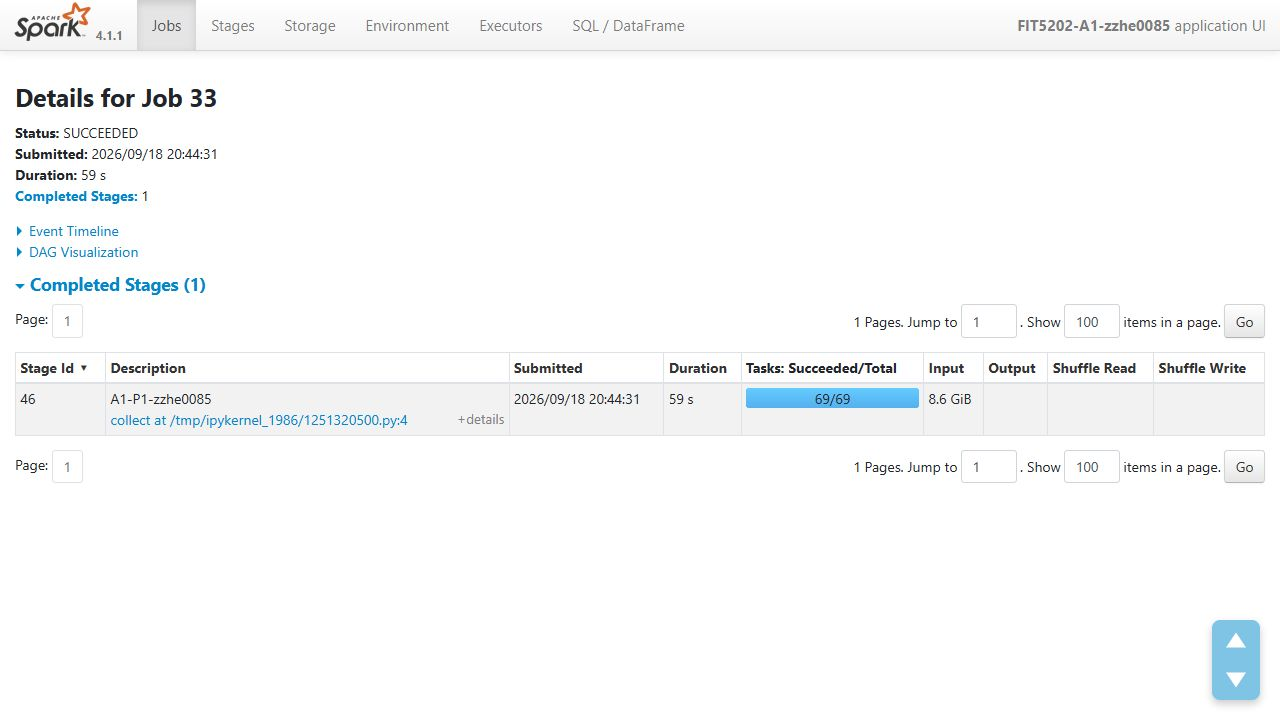

Part 1: actual labelled partition-count job; 69 successful tasks.

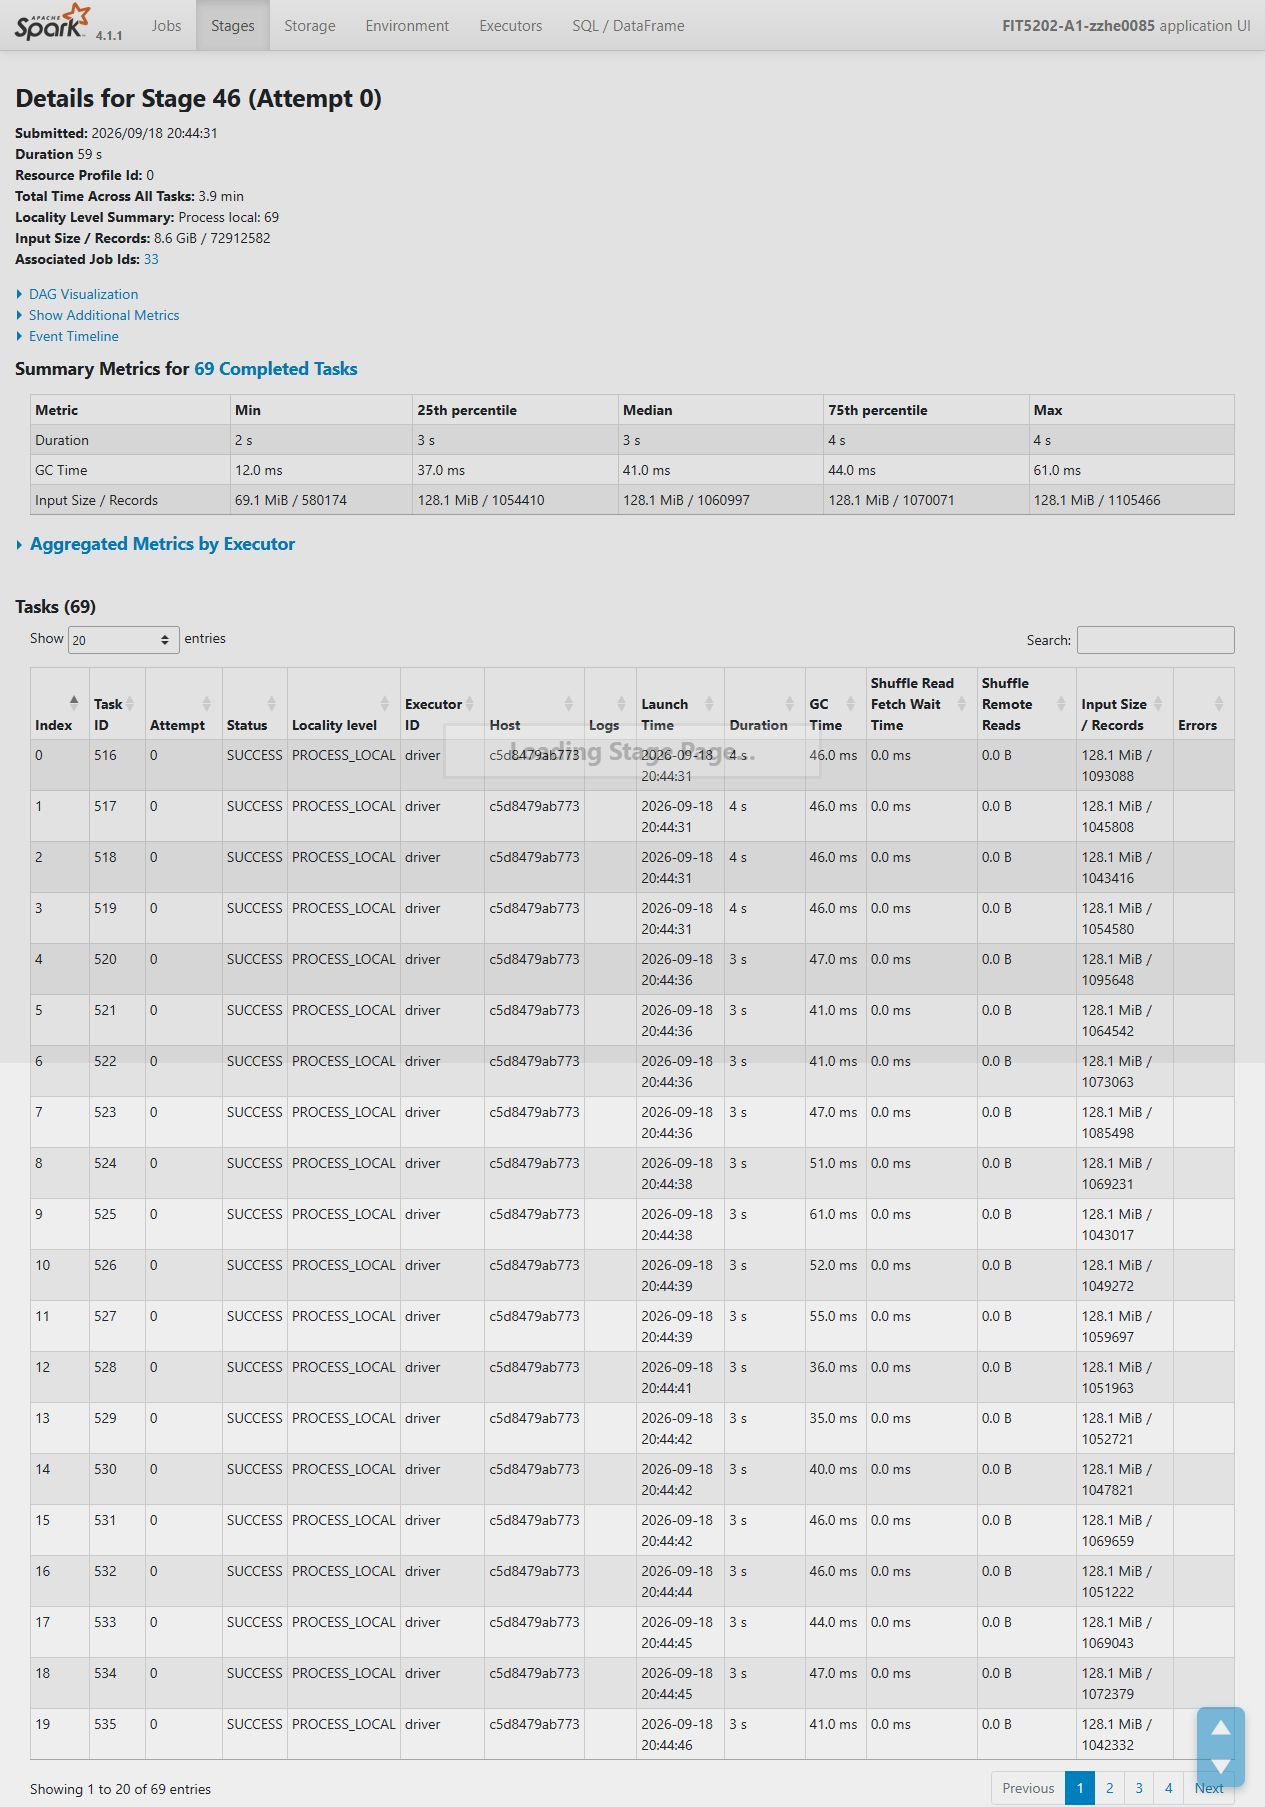

Part 1: input sizes, row counts and duration percentiles for all 69 completed tasks.

1.3.4) Analyse the figures in the screenshot and briefly comment on whether the workload appears evenly distributed across the partitions. If not, why?

In [ ]:
display(Markdown(
    f"The {len(partition_pdf)} partitions contain between {partition_pdf.Records.min():,} "
    f"and {partition_pdf.Records.max():,} rows (mean {partition_pdf.Records.mean():,.1f}; "
    f"coefficient of variation {partition_pdf.Records.std(ddof=0) / partition_pdf.Records.mean():.3f}). "
    "Row counts assess balance but are not interchangeable with bytes or task duration. "
    "Variable-length CSV records and a smaller final split can explain differences. "
    "The screenshots provide stage/task evidence for this specific action."))
print({key: spark.conf.get(key) for key in
       ['spark.sql.files.maxPartitionBytes', 'spark.sql.files.openCostInBytes']})


**Screenshot interpretation:** Stage 46 has 69 completed tasks. Its task-duration quartiles are approximately 3 s, 3 s and 4 s, with a 2-4 s range. Input-size quartiles are approximately 128.1 MiB; the smallest task reads 69.1 MiB. The row-count coefficient of variation is 0.056. These indicate broadly balanced file partitions with a smaller final split. GC time ranges from 12 to 61 ms; duration differences alone do not establish input skew.


1.3.5) Provide a concise explanation detailing how Spark determines the initial number and approximate size of input partitions when reading from a CSV file.

Spark plans file input partitions using splittable file lengths, the configured
`spark.sql.files.maxPartitionBytes`, file-open cost and parallelism-related bounds.
CSV input partitions are approximately byte-sized splits adjusted to record
boundaries, not fixed row-count chunks. Four local cores bound concurrent task
execution; they do not set the input partition count to four. Compression and CSV
multiline options can change splittability. No repartition is performed before this
inspection, so it describes the cleaned input's inherited file partitioning.

## Part 2. Working with DataFrames (35%) <a class="anchor" name="2-dataframes"></a>
In this section, you need to use DataFrame functions to answer the queries.

The following queries use the cleaned DataFrames. Session-count queries require a parsed arrival time and the relevant non-null identifier; duration-based queries also require a valid departure time and a non-negative interval.

2.1 Create the time attributes  
2.1.1) From ArrivalTime, create columns for: year; month; day of week;  arrival hour and arrival minute;.

In [ ]:
parking_time = (parking_clean.withColumn('year', F.year('ArrivalTime'))
    .withColumn('month', F.month('ArrivalTime'))
    .withColumn('DayOfWeek', F.dayofweek('ArrivalTime'))
    .withColumn('ArrivalHour', F.hour('ArrivalTime'))
    .withColumn('ArrivalMinute', F.minute('ArrivalTime'))
    .withColumn('ArrivalDate', F.to_date('ArrivalTime')))


2.1.2) With day of week and hour and minutes, create a new column named isPeak and set the value to True or False (i.e. True = Peak Hour, False = Non-peak hour).  
- Peak hours are:
- Weekdays 7:00 - 9:00 am (excluding 9:00 am) and 4:00 - 6:30 pm ( excluding 6:30 pm).
- Non-peak hours are times outside these periods.
- Represent day of week using Spark’s convention: 1 = Sunday, 2 = Monday……

In [ ]:
minute_of_day = F.col('ArrivalHour') * 60 + F.col('ArrivalMinute')
peak_condition = (F.col('DayOfWeek').between(2, 6)
    & (((minute_of_day >= 420) & (minute_of_day < 540))
       | ((minute_of_day >= 960) & (minute_of_day < 1110))))
parking_time = parking_time.withColumn('isPeak',
    F.when(F.col('ArrivalTime').isNotNull(), peak_condition).otherwise(F.lit(False)))


2.1.3) Display five rows containing ArrivalTime, year, month, day of week, arrival hour, arrival minute and isPeak, and print the relevant schema.

In [ ]:
time_output = parking_time.select('ArrivalTime', 'year', 'month', 'DayOfWeek',
                                  'ArrivalHour', 'ArrivalMinute', 'isPeak')
show_table(time_output, 5)
time_output.printSchema()
print('Invalid arrivals receive isPeak=False for Boolean completeness but are excluded from all session queries.')


2.2 Join the cleaned parking sensor data with both lookup tables to add the area and street names. (Note:The area and street lookup table is provided in JSON format).  
Select an appropriate join type;
- Report the number of parking records that do not match an area look up row and the number that do not match a street lookup row. 
- Identify a suitable join strategy for these joins and justify your choice.
- Display the first five joined records with the following columns: DeviceId, AreaId, AreaName, StreetId, and StreetName.

In [ ]:
for name, frame, key in [('area', area_clean, 'AreaId'), ('street', street_clean, 'StreetId')]:
    duplicates = frame.groupBy(key).count().filter(F.col('count') > 1)
    print(name, 'duplicate lookup keys:', duplicates.count())
    assert duplicates.count() == 0, f'{name} keys must be unique before joining'

# Marker columns distinguish an unmatched key from a matched row with a missing name.
joined = (parking_time
    .join(F.broadcast(area_clean.withColumn('AreaMatched', F.lit(True))), 'AreaId', 'left')
    .join(F.broadcast(street_clean.withColumn('StreetMatched', F.lit(True))), 'StreetId', 'left'))
show_table(joined.agg(F.count('*').alias('JoinedRows'),
    sum_flag(F.col('AreaMatched').isNull()).alias('UnmatchedAreaRecords'),
    sum_flag(F.col('StreetMatched').isNull()).alias('UnmatchedStreetRecords')))
show_table(joined.select('DeviceId', 'AreaId', 'AreaName', 'StreetId', 'StreetName'), 5)

# Project before persistence to keep the reusable full-data input compact.
# Disk persistence avoids assuming that the 9.2 GB CSV fits in available RAM.
prepared = joined.select('DeviceId', 'BayId', 'AreaId', 'AreaName', 'StreetId',
    'ArrivalTime', 'DepartureTime', 'DurationMinutes', 'ValidDuration',
    'InViolation', 'ArrivalDate', 'DayOfWeek', 'isPeak').persist(StorageLevel.DISK_ONLY)
print('Materialised prepared rows:', prepared.count())


Left joins preserve unmatched parking records for explicit quality reporting and
subsequent query-specific validity rules. The tiny area/street lookups are broadcast,
so the large parking side need not be shuffled for these two joins. Name-null rows
are not automatically unmatched: a valid key can map to an unknown name.
Prepared input persistence is shared by both monthly implementations and all timed
monthly variants; its initial materialisation is outside every timed report query.

### 2.3 Compare Parking Activity and Violation Rates
The council would like to compare parking activity and violation patterns during peak and off-peak periods.  
For each parking area:
- PeakDailyAverage: the average number of valid peak-hour sessions per active weekday.
- PeakViolationRate: percentage of valid peak-hour sessions marked as InViolation.
- OffPeakDailyAverage: the average number of valid off-peak sessions per active day.
- OffPeakViolationRate: the percentage of valid off-peak sessions marked as InViolation.
- TotalValidSessions: total peak and off-peak sessions.
1) Display the ten areas with the highest TotalValidSessions, ordered by TotalValidSessions descending. If counts are equal, order by AreaId ascending. 
1) Briefly compare the peak and off-peak results and discuss whether higher parking activity appears to correspond with higher violation rates among these areas.
Note:  
- Violation rate = (sessions where Inviolation is true) / (sessions with a valid Inviolation value in the same period) * 100%.
- A valid session must have a non-null AreaID, and a successfully parsed ArrivalTime. 
- Calculate each violation rate using sessions with a valid InViolation value in the corresponding period.
- A missing DepartureTime does not invalidate a session because duration is not used in this task.
- An active day is a date on which the area has at least one valid parking session.


Daily-average denominators count active dates for each area: all active weekdays for peak sessions, and all active days for off-peak sessions. Violation-rate denominators include only known true/false values in the respective period. Missing departures do not remove sessions from these counts.

In [ ]:
#2.3.1
area_sessions = prepared.filter(F.col('AreaId').isNotNull() & F.col('ArrivalTime').isNotNull())
area_metrics = (area_sessions.groupBy('AreaId', 'AreaName').agg(
    sum_flag(F.col('isPeak')).alias('PeakSessions'),
    sum_flag(~F.col('isPeak')).alias('OffPeakSessions'),
    F.countDistinct(F.when(F.col('DayOfWeek').between(2, 6), F.col('ArrivalDate'))).alias('ActiveWeekdays'),
    F.countDistinct('ArrivalDate').alias('ActiveDays'),
    sum_flag(F.col('isPeak') & (F.col('InViolation') == True)).alias('PeakViolations'),
    sum_flag(F.col('isPeak') & F.col('InViolation').isNotNull()).alias('PeakKnownViolations'),
    sum_flag(~F.col('isPeak') & (F.col('InViolation') == True)).alias('OffPeakViolations'),
    sum_flag(~F.col('isPeak') & F.col('InViolation').isNotNull()).alias('OffPeakKnownViolations'),
    F.count('*').alias('TotalValidSessions'))
    .withColumn('PeakDailyAverage', F.when(F.col('ActiveWeekdays') > 0,
                F.col('PeakSessions') / F.col('ActiveWeekdays')))
    .withColumn('OffPeakDailyAverage', F.col('OffPeakSessions') / F.col('ActiveDays'))
    .withColumn('PeakViolationRate', percentage(F.col('PeakViolations'), F.col('PeakKnownViolations')))
    .withColumn('OffPeakViolationRate', percentage(F.col('OffPeakViolations'), F.col('OffPeakKnownViolations'))))
area_ranked = area_metrics.orderBy(F.desc('TotalValidSessions'), 'AreaId')
show_table(area_ranked.select('AreaId', 'AreaName',
    F.round('PeakDailyAverage', 2).alias('PeakDailyAverage'),
    F.round('PeakViolationRate', 2).alias('PeakViolationRate'),
    F.round('OffPeakDailyAverage', 2).alias('OffPeakDailyAverage'),
    F.round('OffPeakViolationRate', 2).alias('OffPeakViolationRate'), 'TotalValidSessions'), 10)
area_pdf = area_ranked.toPandas()  # Only one row per area.


In [ ]:
#2.3.2
top_areas = area_pdf.head(10)
peak_higher = int((top_areas.PeakViolationRate > top_areas.OffPeakViolationRate).sum())
activity_correlation = top_areas[['TotalValidSessions', 'PeakViolationRate']].corr().iloc[0, 1]
display(Markdown(
    f"Among the ten busiest areas, **{peak_higher}** have a higher peak than off-peak "
    f"violation rate. The descriptive correlation between total sessions and peak "
    f"violation rate in these ten areas is **{activity_correlation:.3f}**. "
    "This is an association in a selected, small group, not evidence that activity "
    "causes violations. Daily averages use different exposure periods: peak daily "
    "counts cover only 4.5 hours on active weekdays, while off-peak counts cover the "
    "remaining periods including weekends. Active weekdays are counted from all valid "
    "sessions, including weekdays with zero peak sessions. Unknown violation values "
    "are excluded from the relevant rate denominator; missing departures are retained."))


### 2.4 Identify high-use and long-stay parking bays  
Parking planners would like to identify bays with frequent vehicle turnover and bays that are commonly occupied for longer periods.  
For each BayId, calculate:  
1. the total number of valid parking sessions;
1. the total number of sessions with a valid duration;
1. the average parking duration in minutes, rounded to two decimal places
1. the percentage of sessions marked as InViolation, rounded to two decimal places  
Identify and display:  
1. the top 5 bays with the highest turnover, order the turnover result by totalSessions descending, use BayID ascending to resolve ties.
1. the top 5 bays with the longest average stay, order the longest-stay result by AverageDurationMinutes descending, use BayID ascending to resolve ties.
1. For both top-5 results, display BayID, TotalSessions, ValidDurationSessions, AverageDurationMinutes and ViolationRates.
Note:  
- A valid session must have a non-null identifier required by the query, a successfully parsed ArrivalTime.
- Define turnover as the total number of valid sessions recorded for a bay during the observation period


In [ ]:
bay_sessions = prepared.filter(F.col('BayId').isNotNull() & F.col('ArrivalTime').isNotNull())
bay_metrics = (bay_sessions.groupBy('BayId').agg(
    F.count('*').alias('TotalSessions'),
    sum_flag(F.col('ValidDuration')).alias('ValidDurationSessions'),
    F.round(F.avg(F.when(F.col('ValidDuration'), F.col('DurationMinutes'))), 2).alias('AverageDurationMinutes'),
    sum_flag(F.col('InViolation') == True).alias('ViolationCount'),
    F.count('InViolation').alias('KnownViolationSessions'))
    .withColumn('ViolationRates', F.round(percentage(F.col('ViolationCount'), F.col('KnownViolationSessions')), 2)))
bay_output = ['BayId', 'TotalSessions', 'ValidDurationSessions', 'AverageDurationMinutes', 'ViolationRates']
print('Top 5 highest turnover bays')
show_table(bay_metrics.orderBy(F.desc('TotalSessions'), 'BayId').select(*bay_output), 5)
print('Top 5 longest average stays')
show_table(bay_metrics.filter(F.col('ValidDurationSessions') > 0)
           .orderBy(F.desc('AverageDurationMinutes'), 'BayId').select(*bay_output), 5)


Turnover is the total number of valid recorded sessions over the observation period,
as specified, rather than an occupancy fraction. The longest-stay ranking excludes
bays with no valid duration. A large average supported by very few valid durations
should be interpreted cautiously; the displayed denominator makes this visible.

### 2.5 Combine parking activity with traffic volume
The council would like to identify when an area experiences unusually high traffic and parking activity at the same time.  
The traffic count dataset is measured by sensors during 10-minute time blocks. A time block begins at 00, 10, 20, 30, 40, or 50 minutes past the hour. For example, times from 00:00:00 inclusive to 00:10:00 exclusive belong to the block beginning at 00:00:00. A traffic record with: 2018, 1, 1, 0, 0 is the first 10-minute block on 1/1/2018, and belongs to the block 2018-01-01 00:00:00 to 2018-01-01 00:09:59.  
For each area-time block:  
- Define ParkingSessions as the number of parking sessions beginning within the block.
- Define TrafficVolume as the sum of traffic_count within the block.

1. Now, you need to think of a strategy to combine parking activity and traffic volume. Select an appropriate join type and justify your choice. 

In [ ]:
print('Observed traffic minute codes:')
show_table(traffic_clean.groupBy('d_minute').count().orderBy('d_minute'))
minute_values = [r.d_minute for r in traffic_clean.select('d_minute').distinct().collect() if r.d_minute is not None]
assert set(minute_values) <= set(range(6)), 'Review traffic encoding before proceeding.'
traffic_minute = (F.col('d_minute') * 10 if TRAFFIC_MINUTE_ENCODING == 'block_index'
                  else F.col('d_minute'))
traffic_timed = traffic_clean.withColumn('BlockStart', F.try_make_timestamp(
    F.col('d_year').cast('int'), F.col('d_month').cast('int'), F.col('d_day').cast('int'),
    F.col('d_hour').cast('int'), traffic_minute.cast('int'), F.lit(0)))
valid_traffic = (F.col('AreaId').isNotNull() & F.col('BlockStart').isNotNull()
                 & F.col('traffic_count').isNotNull() & (F.col('traffic_count') >= 0)
                 & F.col('d_minute').between(0, 5))
show_table(traffic_timed.agg(F.count('*').alias('TotalTrafficRows'),
    sum_flag(valid_traffic).alias('ValidTrafficRows'),
    sum_flag(~F.coalesce(valid_traffic, F.lit(False))).alias('ExcludedTrafficRows')))
parking_blocks = (area_sessions.withColumn('BlockStart', F.window('ArrivalTime', '10 minutes').getField('start'))
    .groupBy('AreaId', 'BlockStart').agg(F.count('*').alias('ParkingSessions')))
traffic_blocks = (traffic_timed.filter(valid_traffic).groupBy('AreaId', 'BlockStart')
    .agg(F.sum('traffic_count').alias('TrafficVolume')))
matched_blocks = parking_blocks.join(traffic_blocks, ['AreaId', 'BlockStart'], 'inner')
sc.setJobDescription(f'A1-P2-TrafficJoin-{student_auth_code}')
matched_blocks.explain(mode='formatted')
matched_blocks = matched_blocks.persist(StorageLevel.DISK_ONLY)


Both inputs are aggregated to one row per `(AreaId, BlockStart)` before joining. This
prevents many-to-many multiplication of parking counts and traffic volume. An inner
join implements the specified matched-block population; an absent observation is
not assumed to be a measured zero. Means are calculated globally across this matched
population, not separately within each area, and the comparison is strictly `>`.

The parking count is arrivals within the half-open ten-minute interval, not the number
of bays occupied throughout that interval. Traffic records in a block are summed,
including multiple sensor measurements. Grouped aggregates and a distributed join
can require hash exchanges by their keys; the physical plan and UI quantify actual
movement. Broadcasting the small name lookup does not eliminate the earlier large
aggregations. Adaptive execution may coalesce shuffle partitions.

2. Across the matched area-time blocks, define high parking activity and high traffic volume as values greater than their respective averages.  
Display a summary containing:  
the average ParkingSessions, average TrafficVolume, number of matched area-time blocks, and the number where both measures are above average.   


In [ ]:
traffic_summary = matched_blocks.agg(F.avg('ParkingSessions').alias('AverageParkingSessions'),
    F.avg('TrafficVolume').alias('AverageTrafficVolume'), F.count('*').alias('MatchedAreaTimeBlocks'))
traffic_summary_values = traffic_summary.first().asDict()
above_average = matched_blocks.filter(
    (F.col('ParkingSessions') > traffic_summary_values['AverageParkingSessions'])
    & (F.col('TrafficVolume') > traffic_summary_values['AverageTrafficVolume']))
traffic_summary_values['BothAboveAverageBlocks'] = above_average.count()
display(pd.DataFrame([traffic_summary_values]))


3. Display the ten above-average combinations with the highest ParkingSessions, display AreaID, AreaName, BlockStart, ParkingSessions, TrafficVolume, order the result by ParkingSessions and TrafficVolume in descending order. If values are equal, order by AreaId and BlockStart in ascending order.

In [ ]:
show_table(above_average.join(F.broadcast(area_clean), 'AreaId', 'left')
    .orderBy(F.desc('ParkingSessions'), F.desc('TrafficVolume'), 'AreaId', 'BlockStart')
    .select('AreaId', 'AreaName', 'BlockStart', 'ParkingSessions', 'TrafficVolume'), 10)
traffic_evidence = evidence_snapshot('P2_traffic_join')


4. Before running the query, you must set:  
sc.setJobDescription(f"A1-P2-TrafficJoin-{student_auth_code}")  
Students must include:  
- the formatted physical plan using explain(mode="formatted");
- Spark UI screenshots showing the job description, any Exchange, and the relevant shuffle-read, shuffle-write values.
- a short explanation of why data movement was or was not required.


The required job description is set before materialising the matched-block query in Question 2.5.1, where the formatted physical plan is printed.

**Observed execution:** Query 34 (Jobs 77-81, captured from this application) uses a SortMergeJoin after the two aggregations. The parking Exchange in Stage 120 writes 172.2 MiB and the traffic Exchange writes 45.6 MiB; the joining stage, Stage 124, reads 217.7 MiB across 32 tasks. Thus data movement was required to bring common area-time keys together. Shuffle remote reads are zero because execution is local; this does not mean shuffle itself was avoided. The UI input-record count for a cached columnar scan can count batches, so it should not be interpreted as the number of original parking sessions.

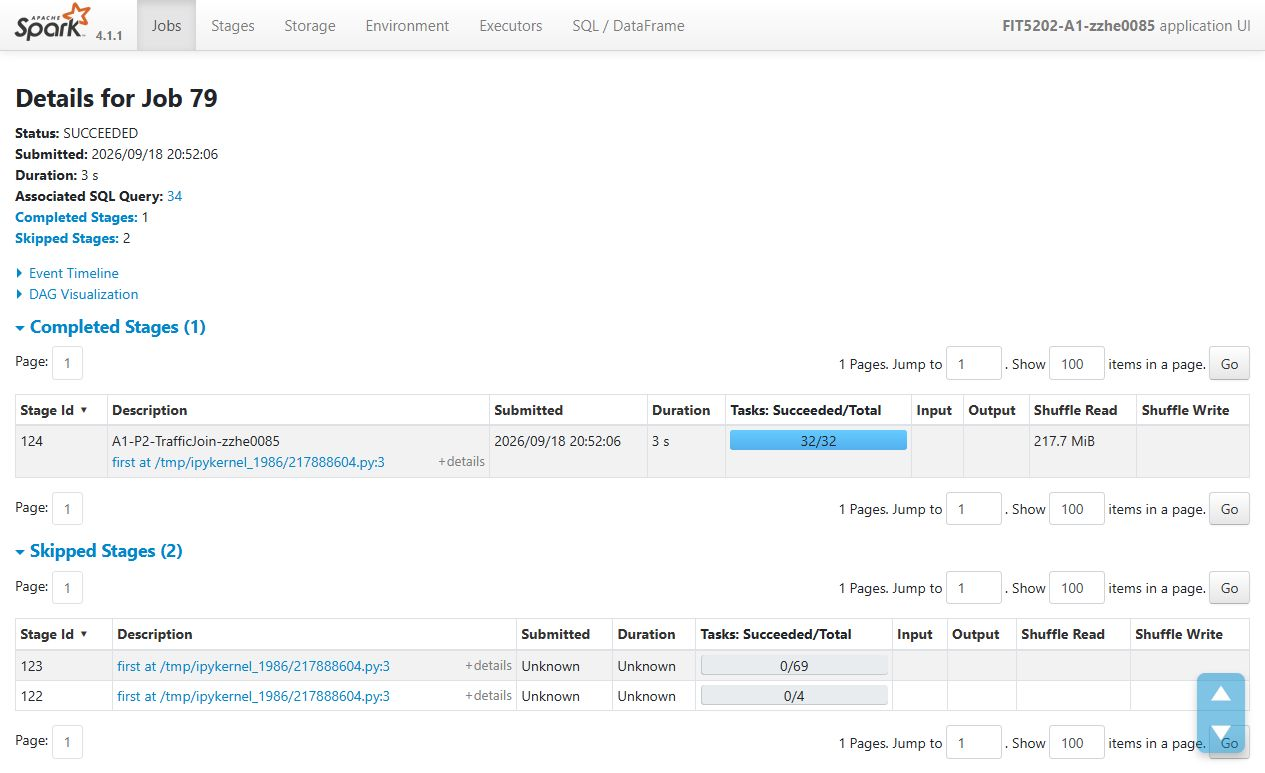

Part 2: labelled traffic-join job and corresponding SQL execution.

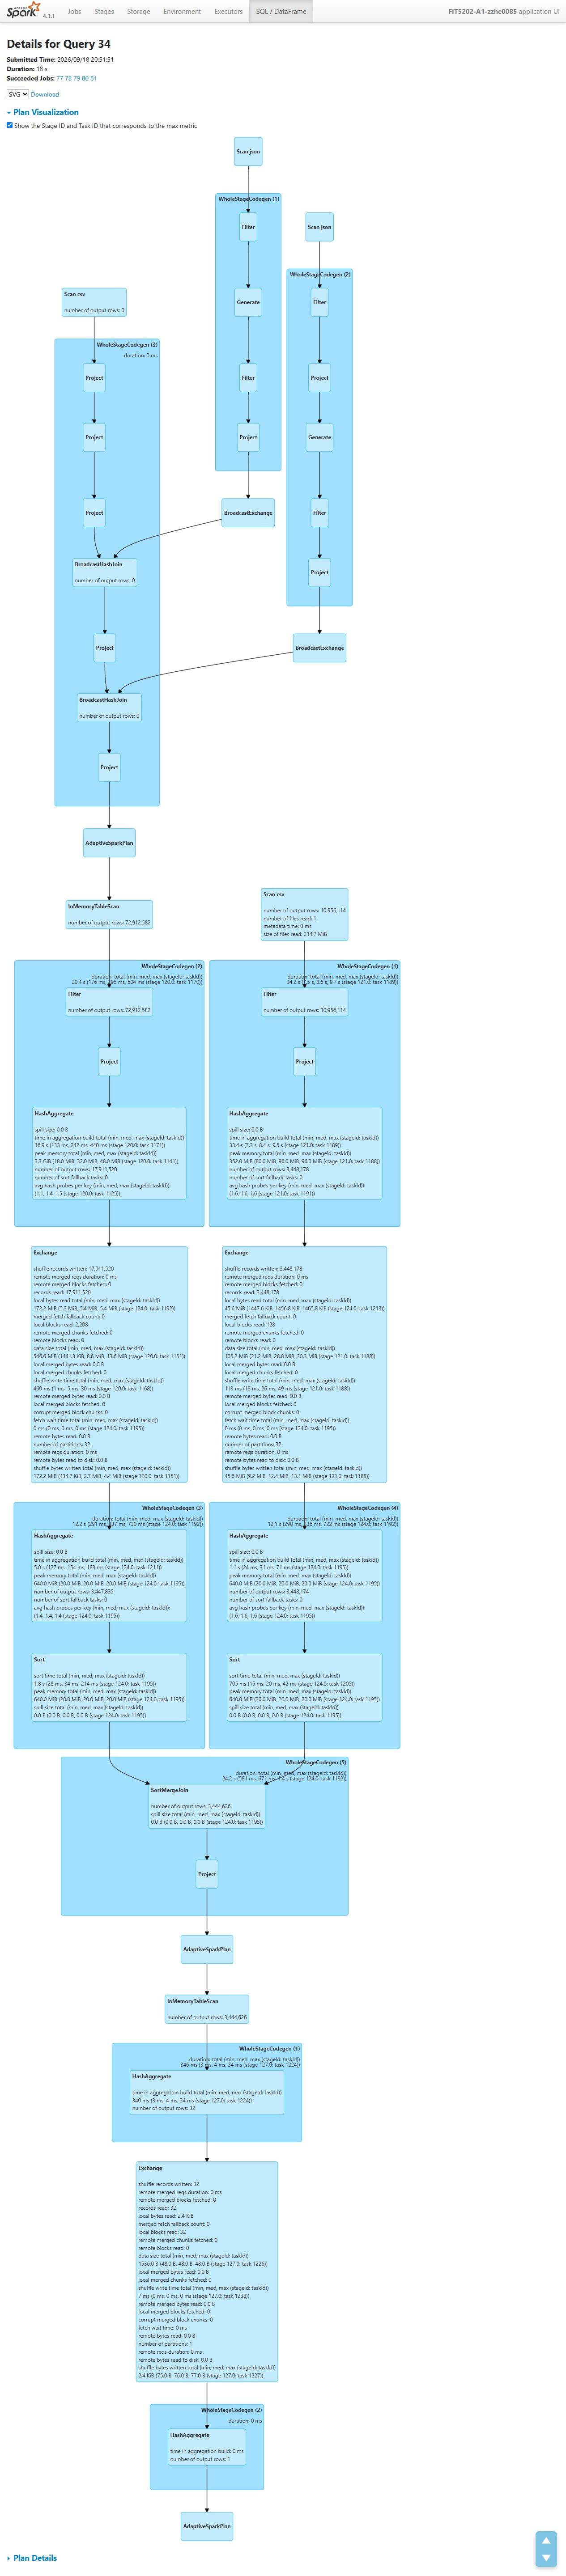

Part 2: actual SQL graph showing SortMergeJoin, Exchanges and their measured shuffle metrics.

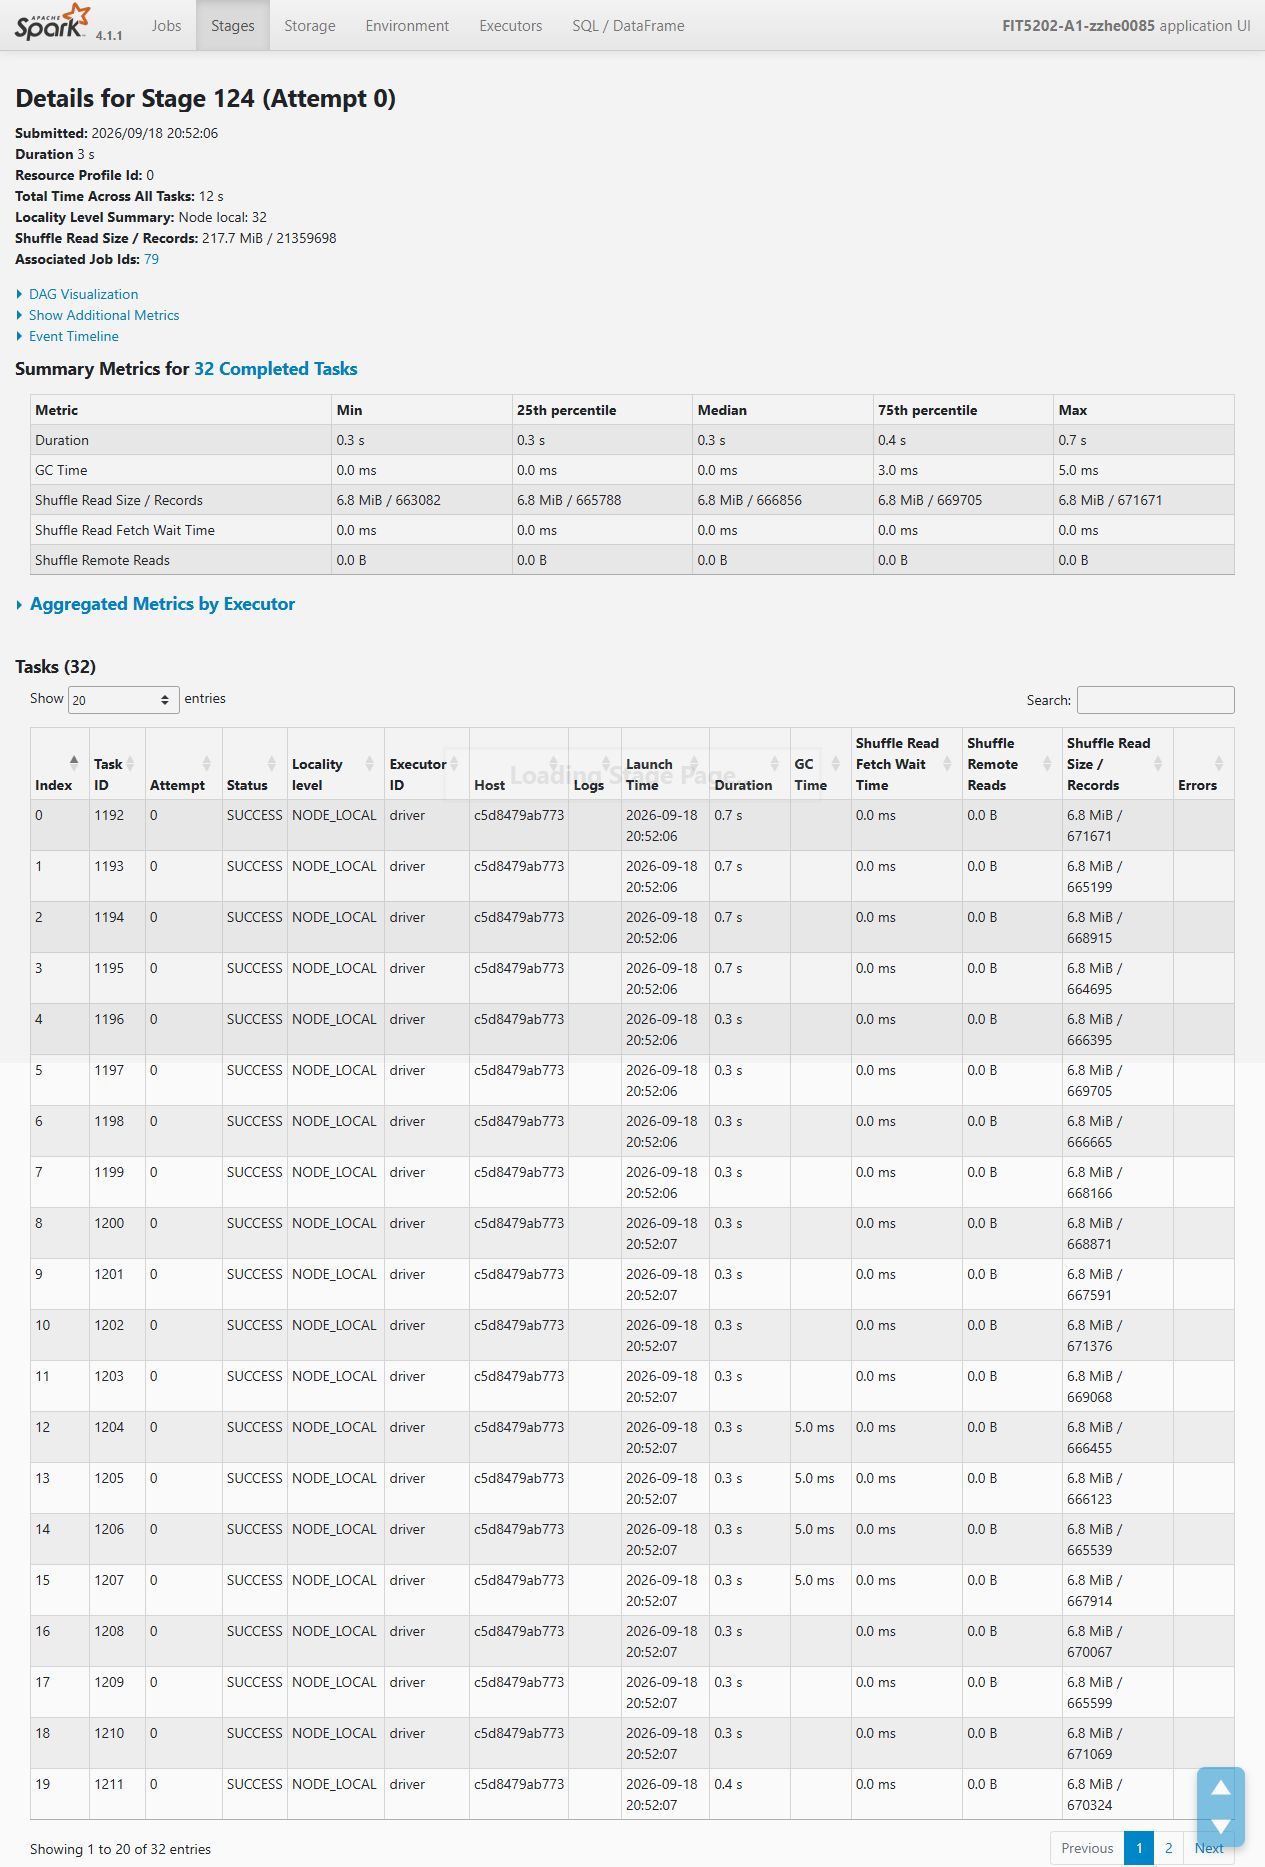

Part 2: join stage reads 217.7 MiB across 32 tasks.

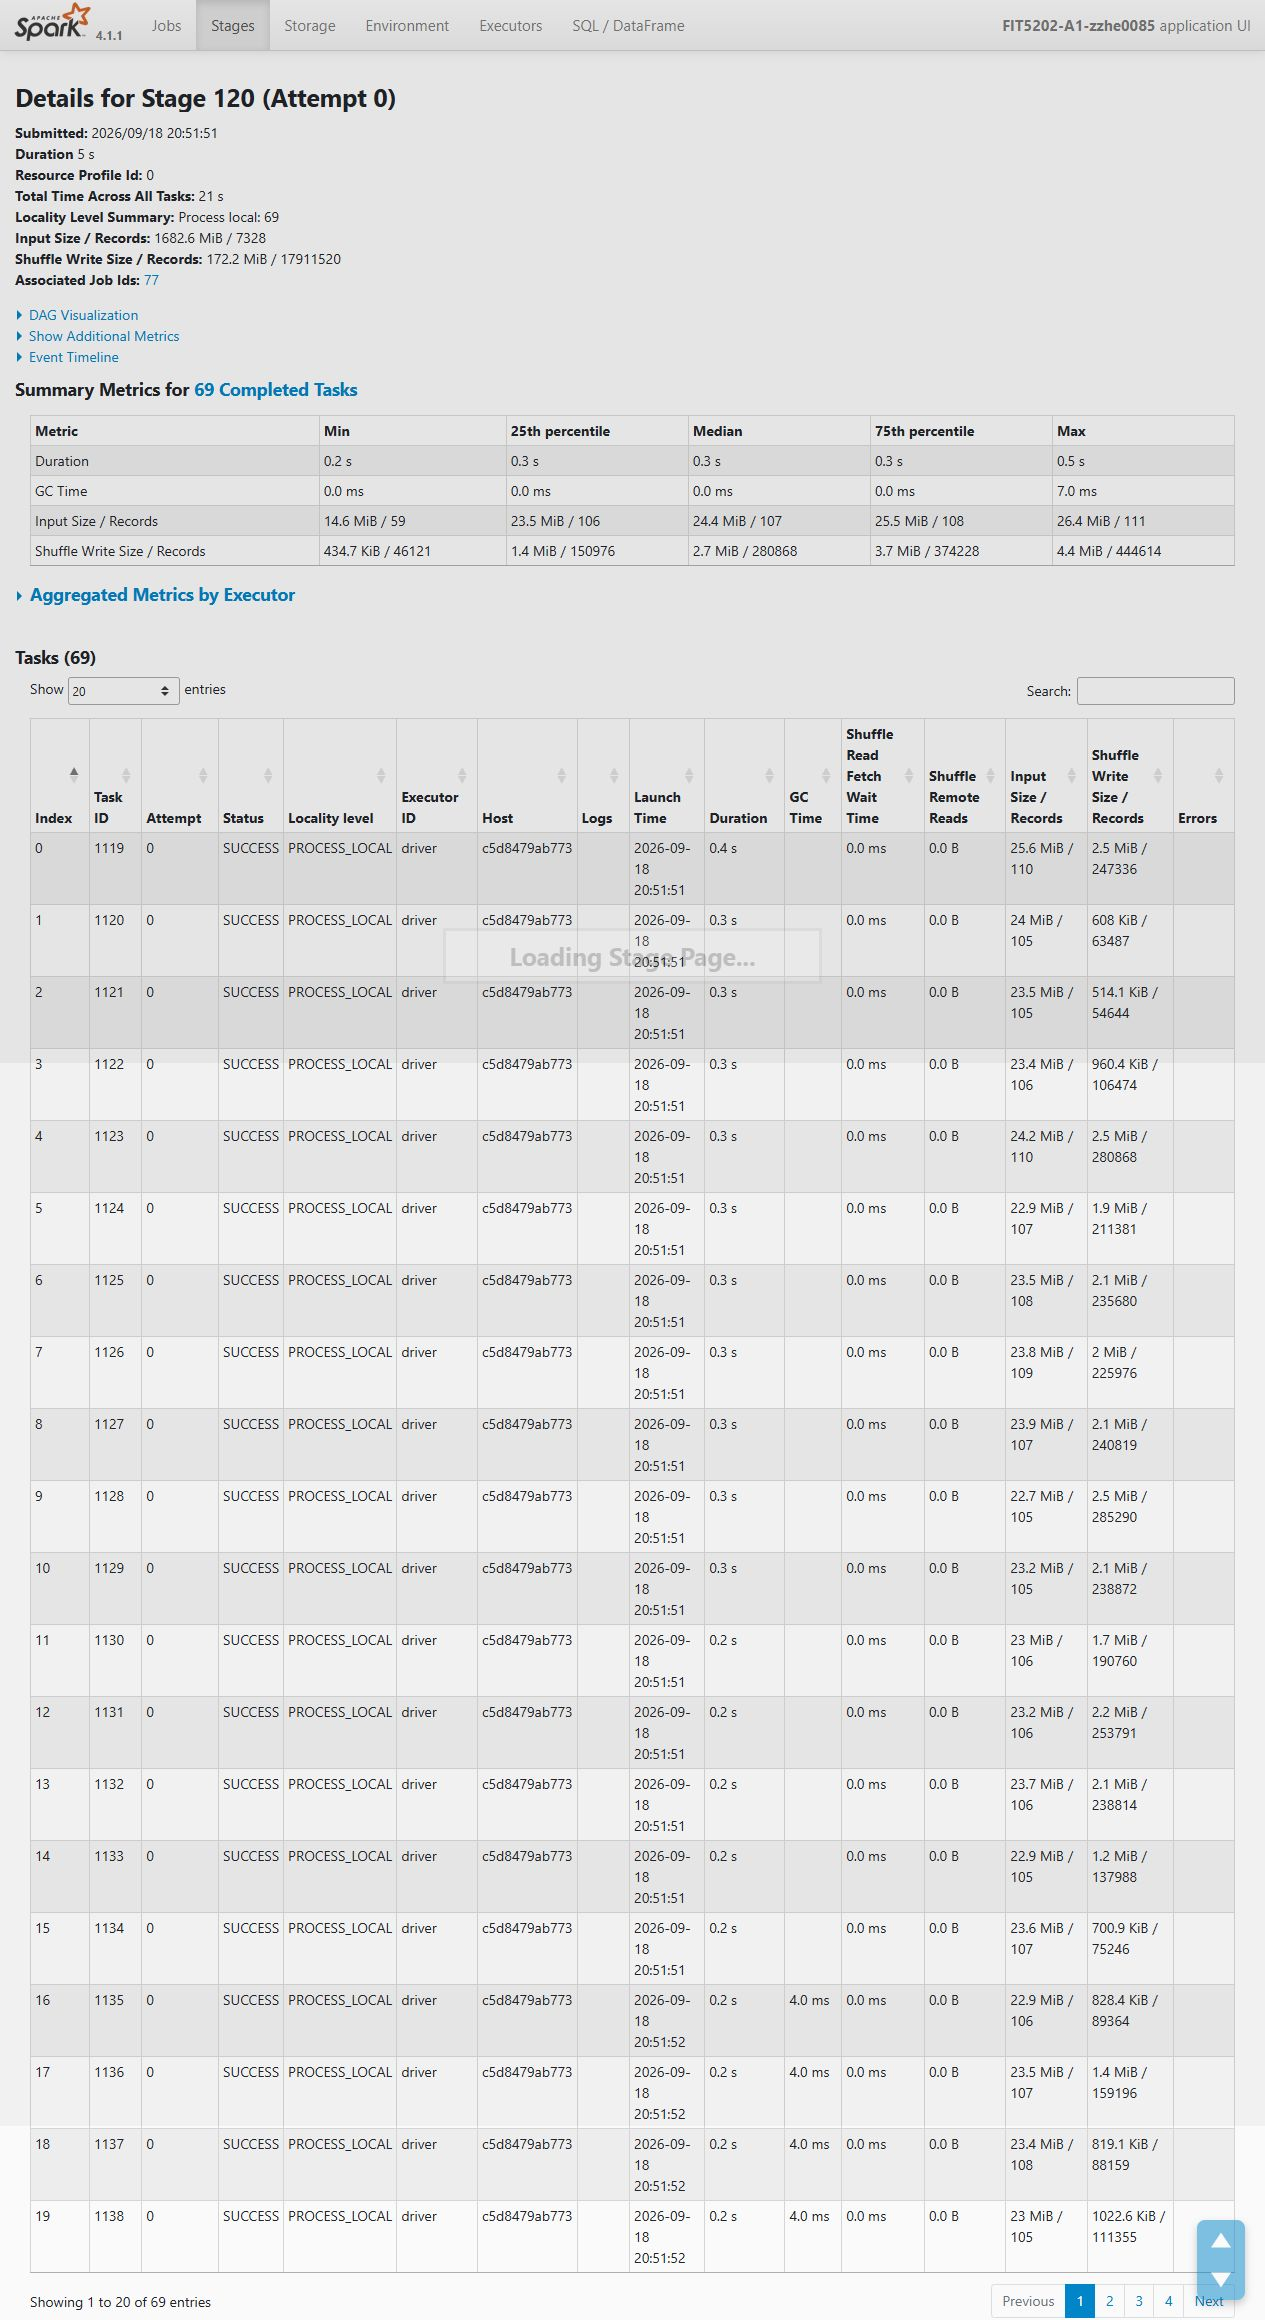

Part 2: parking aggregation writes 172.2 MiB before the join.

### 2.6 Exploratory analysis  <a class="anchor" name="2.6"></a>
Produce two suitable plots exploring relationships among parking activity, duration, violation rate, or traffic volume.  
For each plot:
1. State the question being investigated;
1. Display the first five rows and the row count of the aggregated dataset used to create the plot
1. Select the appropriate plot type and briefly justify your choice.
1. Explain the observed pattern shown by the plot.
1. identify one limitation of the interpretation.


In [ ]:
plot1 = area_metrics.select('AreaId', 'AreaName', 'PeakDailyAverage', 'PeakViolationRate')
print('Plot 1 aggregated rows:', plot1.count())
show_table(plot1.orderBy('AreaId'), 5)
plot1_pdf = plot1.orderBy('AreaId').toPandas().dropna(subset=['PeakDailyAverage', 'PeakViolationRate'])


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(plot1_pdf.PeakDailyAverage, plot1_pdf.PeakViolationRate, color='#176b87', alpha=.8)
ax.set(xlabel='Peak sessions per active weekday', ylabel='Peak violation rate (%)',
       title='Area-level peak parking activity and violations')
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()
plot1_corr = plot1_pdf[['PeakDailyAverage', 'PeakViolationRate']].corr().iloc[0, 1]
display(Markdown(
    f"**Question:** Do areas with greater peak daily activity also have higher peak violation rates? "
    f"A scatter plot compares two quantitative variables without implying a time ordering. "
    f"Across **{len(plot1_pdf)}** areas with both measures observed, Pearson r is **{plot1_corr:.3f}**; "
    "the point spread shows how consistently the relationship holds. **Limitation:** "
    "area-level association can reflect differences in bay capacity, restrictions or enforcement; "
    "it does not establish an individual driver's behaviour or a causal effect."))


In [ ]:
# One point per area averages only its matched blocks; at most a few dozen rows leave Spark.
plot2 = matched_blocks.groupBy('AreaId').agg(
    F.avg('ParkingSessions').alias('MeanParkingSessions'),
    F.avg('TrafficVolume').alias('MeanTrafficVolume'),
    F.count('*').alias('MatchedBlocks'))
print('Plot 2 aggregated rows:', plot2.count())
show_table(plot2.orderBy('AreaId'), 5)
plot2_pdf = plot2.orderBy('AreaId').toPandas()


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(plot2_pdf.MeanTrafficVolume, plot2_pdf.MeanParkingSessions, color='#b35a32', alpha=.8)
ax.set(xlabel='Mean traffic volume per matched ten-minute block',
       ylabel='Mean parking arrivals per matched ten-minute block',
       title='Traffic volume and parking activity across areas')
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()
plot2_corr = plot2_pdf[['MeanTrafficVolume', 'MeanParkingSessions']].corr().iloc[0, 1]
display(Markdown(
    f"**Question:** Do areas with higher mean traffic volume also have more parking arrivals "
    f"per matched block? A scatter plot shows both quantitative measures directly. "
    f"Across **{len(plot2_pdf)}** areas, Pearson r is **{plot2_corr:.3f}**. "
    "**Limitation:** aggregation hides within-area time variation, and matched blocks "
    "exclude unobserved blocks. Sensor coverage also limits interpretation; "
    "traffic counts alone are not a measure of congestion speed."))
matched_blocks.unpersist()


**Patterns in the plots:** Plot 1 has a weak negative linear association (r = −0.104), so a general increase in violation rate with peak activity is not supported across all 38 areas. This differs from the selected top-ten comparison and illustrates selection effects. Plot 2 shows an almost straight increasing relationship between the two area means (r = 0.999). Such a strong association in this remixed assignment dataset should not be generalized to real-world congestion or interpreted as proof of causation.

## Part 3 Query Optimisation (25%) <a class="anchor" name="part-3"></a>
Assume that the following monthly parking report will be generated regularly. A correct query is required first, but it should also execute efficiently on the full dataset. In this section, implement the report, inspect how Spark executes it, and evaluate the optimization.


Monthly parking report  
For each month, identify the five areas with the highest number of peak-hour parking sessions among areas whose peak-hour violation rate is greater than the monthly violation benchmark.  
Area Violation Rate = (Peak-hour sessions where inViolation is true) / (Peak-hour sessions with a valid inViolation value) * 100   
Monthly Violation Benchmark = (Peak-hour sessions where InViolation is true across all areas in the month) / (Peak-hour sessions with a valid InViolation value across all areas in the same month) * 100  
  
Display:  
- month;
- area id;
- area name;
- park session count;
- violation count;
- violation rate;
- monthly rank.  
Report the number of months and total result rows, Display the complete result ordered by Month and Monthly Rank in ascending order.

Monthly input retains valid area sessions and uses `yyyy-MM` so years cannot be
accidentally combined. Rates use only known true/false violation values. An area's
zero known-value denominator yields a null rate and cannot pass the benchmark test.
The monthly benchmark is a ratio of pooled counts, not a mean of area percentages.
The eligibility filter is applied before ranking. A deterministic `AreaId` tie-breaker
and `row_number` return at most five areas per month. Comparisons use unrounded
rates; presentation rounding is not used to change eligibility.

##### 3.1 DataFrame API and Spark SQL 
Implement the monthly report independently using:  
1. the PySpark DataFrame API;
2. Spark SQL  
Both implementations must begin with the same prepared input data. Do not create the SQL result by registering the completed DataFrame API result as a temporary view.  
  
Complete the following:  
1. Report the row count returned by each implementation
2. Confirm that the results are identical using exceptAll() in both directions, and display both mismatch counts.
3. For each implementation, display the first 20 result rows using the following column order: 
- Month
- AreaId
- AreaName
- PeakSessionCount
- ViolationCount
- ViolationRate
- MonthlyViolationBenchmark
- MonthlyRank
4. Order the displayed results by Month and MonthlyRank in ascending order.
5. Inspect the physical plan for each implementation, and briefly compare the operations. Briefly explain whether Spark selected different execution strategies, and why?


In [ ]:
monthly_input = area_sessions.select(
    F.date_format('ArrivalTime', 'yyyy-MM').alias('Month'), 'AreaId', 'AreaName', 'isPeak', 'InViolation')
monthly_input.createOrReplaceTempView('monthly_input')
REPORT_COLUMNS = ['Month', 'AreaId', 'AreaName', 'PeakSessionCount', 'ViolationCount',
                  'ViolationRate', 'MonthlyViolationBenchmark', 'MonthlyRank']

def area_peak_counts():
    return monthly_input.filter('isPeak').groupBy('Month', 'AreaId', 'AreaName').agg(
        F.count('*').alias('PeakSessionCount'),
        sum_flag(F.col('InViolation') == True).alias('ViolationCount'),
        F.count('InViolation').alias('KnownViolationCount'))

def finish_report(frame):
    eligible = (frame.withColumn('ViolationRate', percentage(F.col('ViolationCount'), F.col('KnownViolationCount')))
                .filter(F.col('ViolationRate') > F.col('MonthlyViolationBenchmark')))
    rank_window = Window.partitionBy('Month').orderBy(F.desc('PeakSessionCount'), F.asc('AreaId'))
    return (eligible.withColumn('MonthlyRank', F.row_number().over(rank_window))
            .filter(F.col('MonthlyRank') <= 5).select(*REPORT_COLUMNS).orderBy('Month', 'MonthlyRank'))

def dataframe_report():
    areas = area_peak_counts()
    benchmarks = (monthly_input.filter('isPeak').groupBy('Month').agg(
        sum_flag(F.col('InViolation') == True).alias('MonthlyViolationCount'),
        F.count('InViolation').alias('MonthlyKnownCount'))
        .withColumn('MonthlyViolationBenchmark', percentage(F.col('MonthlyViolationCount'), F.col('MonthlyKnownCount')))
        .select('Month', 'MonthlyViolationBenchmark'))
    return finish_report(areas.join(benchmarks, 'Month', 'inner'))

MONTHLY_SQL = """
WITH peak AS (
    SELECT Month, AreaId, AreaName, InViolation FROM monthly_input WHERE isPeak = true
), area_counts AS (
    SELECT Month, AreaId, AreaName, COUNT(*) AS PeakSessionCount,
           SUM(CASE WHEN InViolation = true THEN 1 ELSE 0 END) AS ViolationCount,
           COUNT(InViolation) AS KnownViolationCount
    FROM peak GROUP BY Month, AreaId, AreaName
), month_counts AS (
    SELECT Month, SUM(CASE WHEN InViolation = true THEN 1 ELSE 0 END) AS MonthlyViolationCount,
           COUNT(InViolation) AS MonthlyKnownCount
    FROM peak GROUP BY Month
), rates AS (
    SELECT a.*, CASE WHEN a.KnownViolationCount > 0
                    THEN CAST(a.ViolationCount AS DOUBLE) / a.KnownViolationCount * 100.0 END AS ViolationRate,
           CASE WHEN m.MonthlyKnownCount > 0
                THEN CAST(m.MonthlyViolationCount AS DOUBLE) / m.MonthlyKnownCount * 100.0 END AS MonthlyViolationBenchmark
    FROM area_counts a JOIN month_counts m ON a.Month = m.Month
), ranked AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY Month ORDER BY PeakSessionCount DESC, AreaId ASC) AS MonthlyRank
    FROM rates WHERE ViolationRate > MonthlyViolationBenchmark
)
SELECT Month, AreaId, AreaName, PeakSessionCount, ViolationCount, ViolationRate,
       MonthlyViolationBenchmark, MonthlyRank
FROM ranked WHERE MonthlyRank <= 5 ORDER BY Month, MonthlyRank
"""
df_report = dataframe_report()
sql_report = spark.sql(MONTHLY_SQL)
df_rows, sql_rows = df_report.collect(), sql_report.collect()
print('DataFrame result rows:', len(df_rows), 'SQL result rows:', len(sql_rows))
print('Result months:', len({row.Month for row in df_rows}))
print('Input months:', monthly_input.select('Month').distinct().count())

# Freeze fully computed results before repeated equality/display checks.
df_result = spark.createDataFrame(df_rows, df_report.schema)
sql_result = spark.createDataFrame(sql_rows, sql_report.schema)
df_minus_sql = df_result.exceptAll(sql_result).count()
sql_minus_df = sql_result.exceptAll(df_result).count()
print('DataFrame minus SQL:', df_minus_sql, 'SQL minus DataFrame:', sql_minus_df)
assert df_minus_sql == sql_minus_df == 0
print('DataFrame first 20:')
show_table(df_result.orderBy('Month', 'MonthlyRank'), 20)
print('SQL first 20:')
show_table(sql_result.orderBy('Month', 'MonthlyRank'), 20)
print('Complete monthly report:')
show_table(df_result.orderBy('Month', 'MonthlyRank'), max(1, len(df_rows)))
print('DataFrame formatted plan:')
df_report.explain(mode='formatted')
print('SQL formatted plan:')
sql_report.explain(mode='formatted')
print('Optimized logical plans equivalent:',
      df_report._jdf.queryExecution().optimizedPlan().sameResult(sql_report._jdf.queryExecution().optimizedPlan()))


Both versions independently express filters, per-area and monthly aggregates, a
benchmark join, an eligibility filter, a window rank and final ordering. Spark's
Catalyst optimizer processes both APIs, so changing syntax alone does not guarantee
a different execution strategy. Inspect the printed plans for actual scan, aggregate,
exchange, join and window operators; expression IDs and CTE aliases are not themselves
different algorithms. Adaptive final plans may differ from initial plans because of
runtime statistics. The bidirectional multiset check includes all eight columns,
including the benchmark and deterministic rank.

**Observed comparison:** both final monthly plans choose a BroadcastHashJoin; the DataFrame plan builds the left side and the SQL plan builds the left side. Both retain hash aggregations, adaptive shuffle reads, sorting and window ranking. The printed optimized-logical-plan sameResult check is not the same as result equality: it can be false for distinct expressions/plan shapes even though bidirectional exceptAll proves these outputs equal. Both aggregated join inputs are small enough for broadcasting. Differing logical expression placement and adaptive runtime statistics can lead to different build-side choices; the observations do not establish that one API is inherently faster.

##### 3.2 Baseline plan and Spark UI analysis  
Select either SQL or DataFrame API from Section 3.1 as a baseline. Clearly state which implementation you selected.  
Before running the baseline query, set: sc.setJobDescription(f"A1-P3-2-Baseline-{student_auth_code}")  
Execute an action that materialises the complete final result and record the wall-clock execution time. Use the same action later when evaluating the optimised query.  
Submit and include:  
- the formatted physical plan, you may refer to the plan already printed in Section 3.1 rather than printing it again.
- Spark UI screenshots clearly showing: the job description, the SQL/DAG, the relevant stage details, relevant shuffle-read, shuffle-write figures, where applicable.
- the measured execution time;  
In no more than 300 words:  
1. Identify the most expensive stages or operations.
2. Support the explanation using numbers visible in your screenshots.
3. Suggest an improvement strategy.


In [ ]:
def timed_report(factory, description, snapshot_name):
    # Build before timing: measure a complete collect action, not lazy construction.
    query = factory()
    sc.setJobDescription(description)
    started = time.perf_counter()
    rows = query.collect()
    elapsed = time.perf_counter() - started
    evidence = evidence_snapshot(snapshot_name)
    return query, rows, elapsed, evidence

baseline_query, baseline_rows, baseline_seconds, baseline_evidence = timed_report(
    dataframe_report, f'A1-P3-2-Baseline-{student_auth_code}', 'P3_baseline')
print('Baseline: DataFrame API; complete collect wall-clock seconds:', baseline_seconds)
print('Materialised result rows:', len(baseline_rows))
baseline_query.explain(mode='formatted')

def labelled_stage_metrics(snapshot, label):
    jobs = [job for job in snapshot.get('jobs', []) if label in (job.get('description') or '')]
    stage_ids = {stage for job in jobs for stage in job.get('stageIds', [])}
    records = []
    for stage in snapshot.get('stages', []):
        if stage.get('stageId') in stage_ids and stage.get('status') == 'COMPLETE':
            records.append({key: stage.get(key, 0) for key in
                ['stageId', 'numTasks', 'executorRunTime', 'inputBytes', 'inputRecords',
                 'shuffleReadBytes', 'shuffleWriteBytes', 'memoryBytesSpilled', 'diskBytesSpilled']})
    return pd.DataFrame(records).sort_values('executorRunTime', ascending=False) if records else pd.DataFrame()

baseline_metrics = labelled_stage_metrics(baseline_evidence, f'A1-P3-2-Baseline-{student_auth_code}')
display(baseline_metrics)
if len(baseline_metrics):
    expensive = baseline_metrics.iloc[0]
    display(Markdown(
        f"The DataFrame baseline materialised {len(baseline_rows)} rows in "
        f"**{baseline_seconds:.3f} seconds**. Its largest stage by summed task executor time "
        f"was stage **{int(expensive.stageId)}**, with **{int(expensive.numTasks)} tasks** and "
        f"**{int(expensive.executorRunTime):,} ms** executor time. Across the associated "
        f"completed stages, shuffle read was **{int(baseline_metrics.shuffleReadBytes.sum()):,} bytes** "
        f"and shuffle write **{int(baseline_metrics.shuffleWriteBytes.sum()):,} bytes**. "
        "Summed task time is not wall-clock time because tasks overlap. The baseline "
        "plan computes per-area counts and a monthly benchmark through separate input "
        "branches, then joins them. I propose deriving the benchmark by window sums "
        "over the already aggregated area counts. This removes the independent monthly "
        "input aggregation and benchmark join while preserving the pooled numerator "
        "and denominator. The remaining window works on area-month rows rather than "
        "individual sessions. The screenshots corroborate these stage figures."))


The DataFrame baseline materialised 120 rows in **5.930 seconds**. Its largest stage by summed task executor time was stage **246**, with **69 tasks** and **12,978 ms** executor time. Across the associated completed stages, shuffle read was **794,109 bytes** and shuffle write **736,800 bytes**. Summed task time is not wall-clock time because tasks overlap. The baseline plan computes per-area counts and a monthly benchmark through separate input branches, then joins them. I propose deriving the benchmark by window sums over the already aggregated area counts. This removes the independent monthly input aggregation and benchmark join while preserving the pooled numerator and denominator. The remaining window works on area-month rows rather than individual sessions. The screenshots corroborate these stage figures.

#### Baseline Spark UI evidence

Run: 18 September 2026, Query 52, Jobs 130-135. The source aggregation is Stage 246; Stage 249 reads its 654.7 KiB shuffle output. The 5.930 s measurement covers the full collect action, which comprises multiple Spark jobs; the 3 s duration displayed for Job 130 covers only that job.

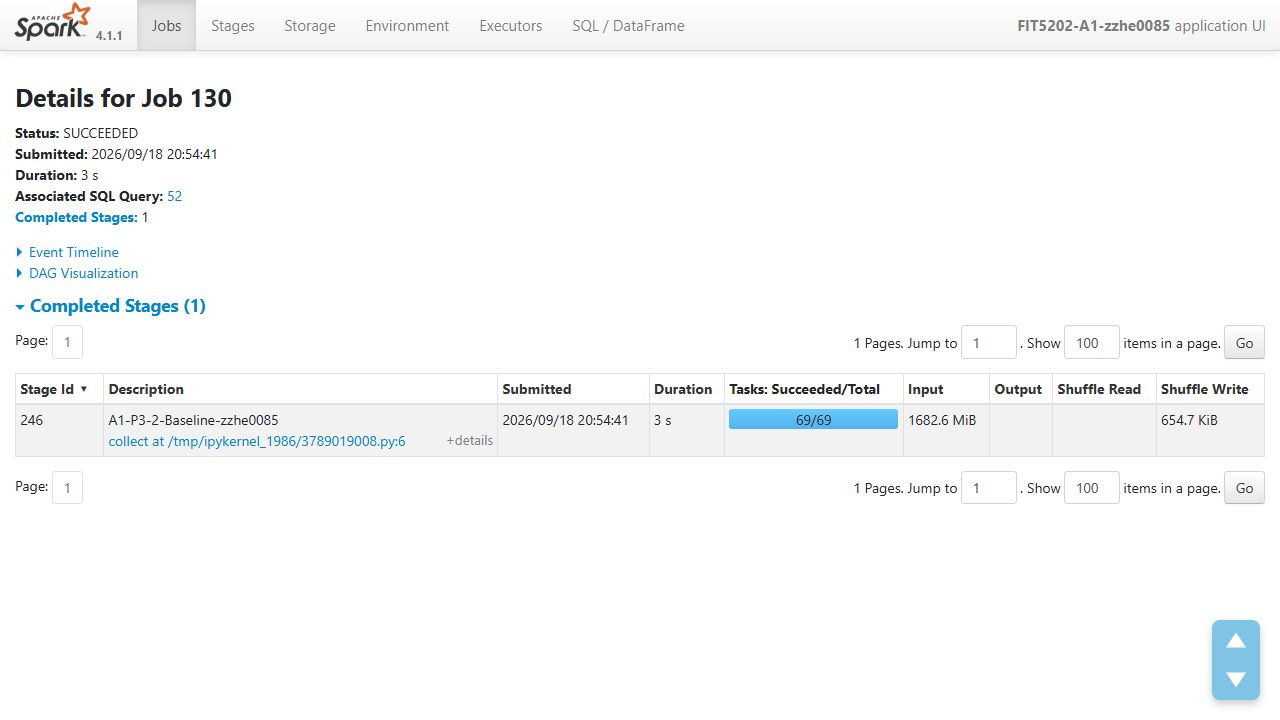

Part 3.2: latest baseline job with the required auth-code label.

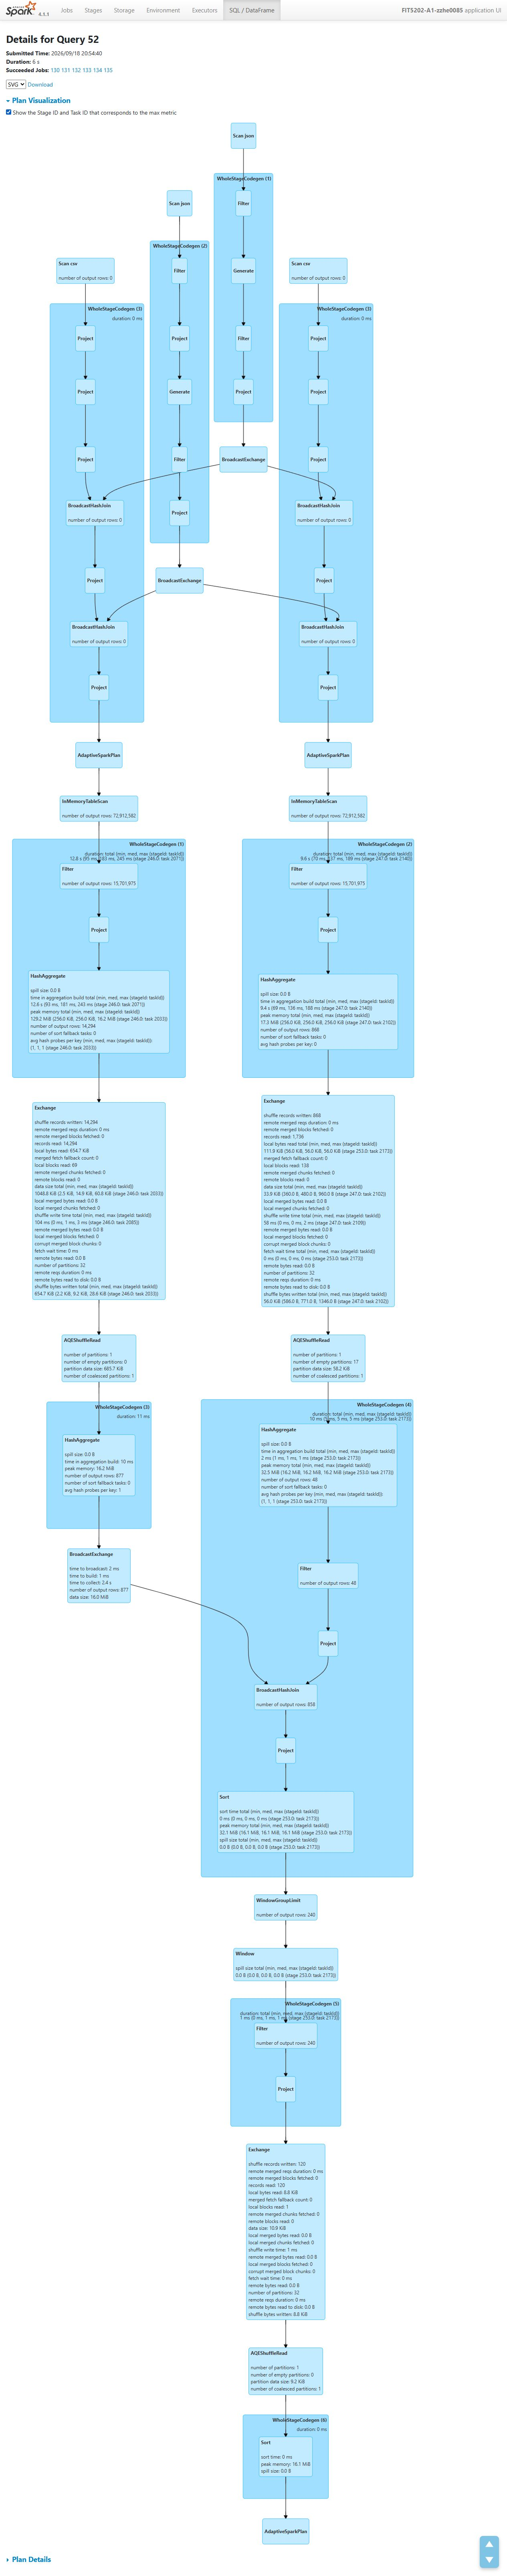

Part 3.2: latest complete SQL graph, including both aggregation branches and benchmark join.

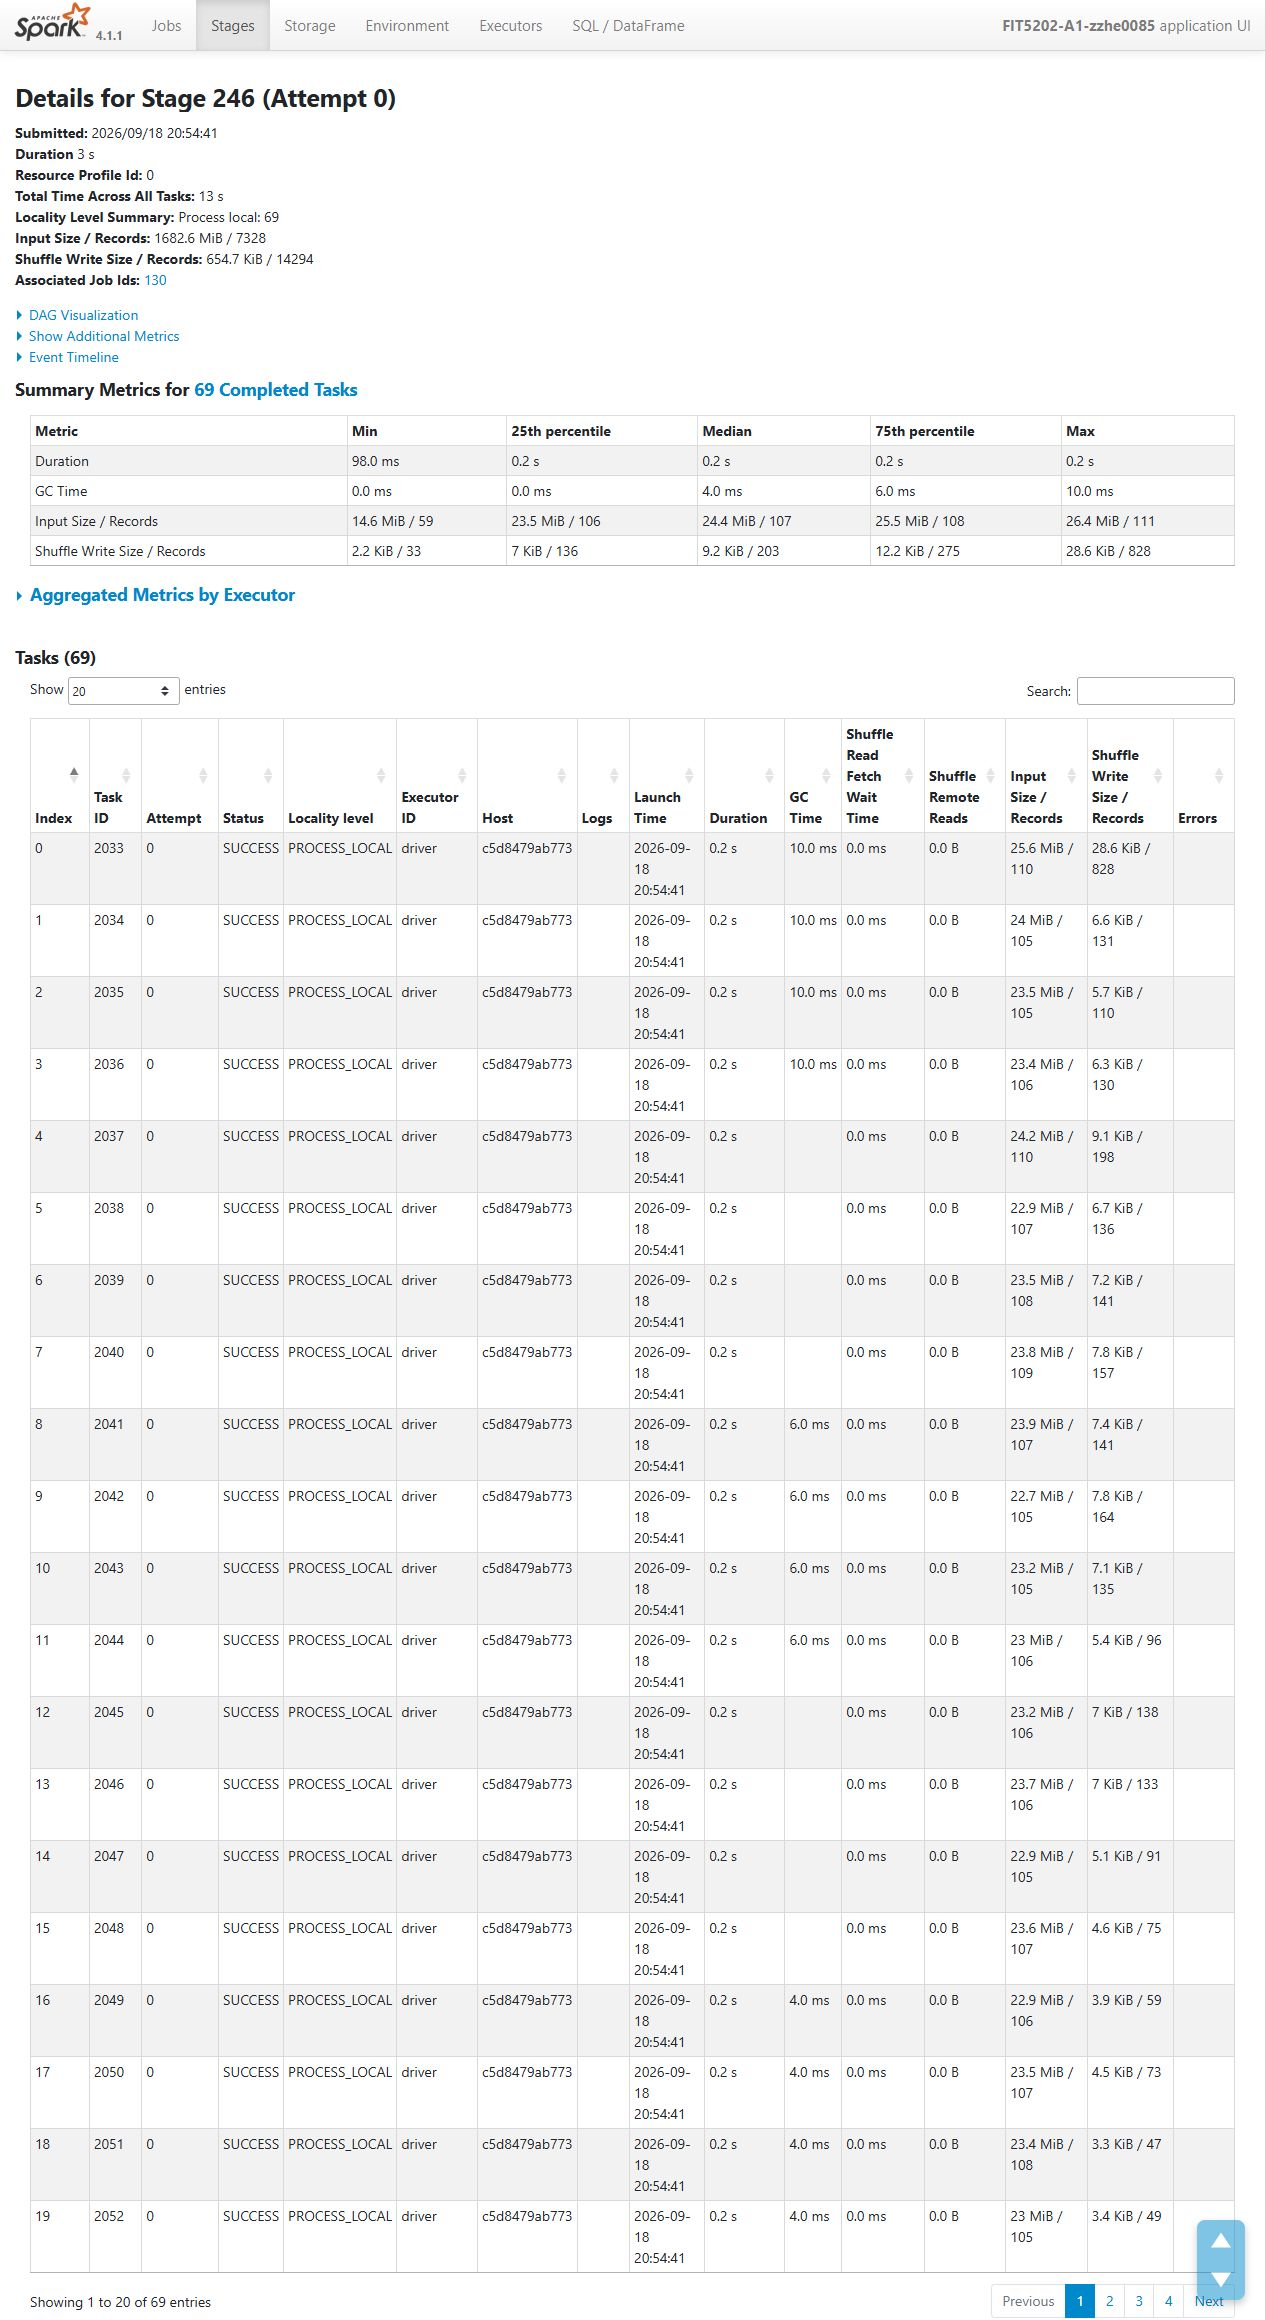

Part 3.2: latest baseline source aggregation stage and task-distribution metrics.

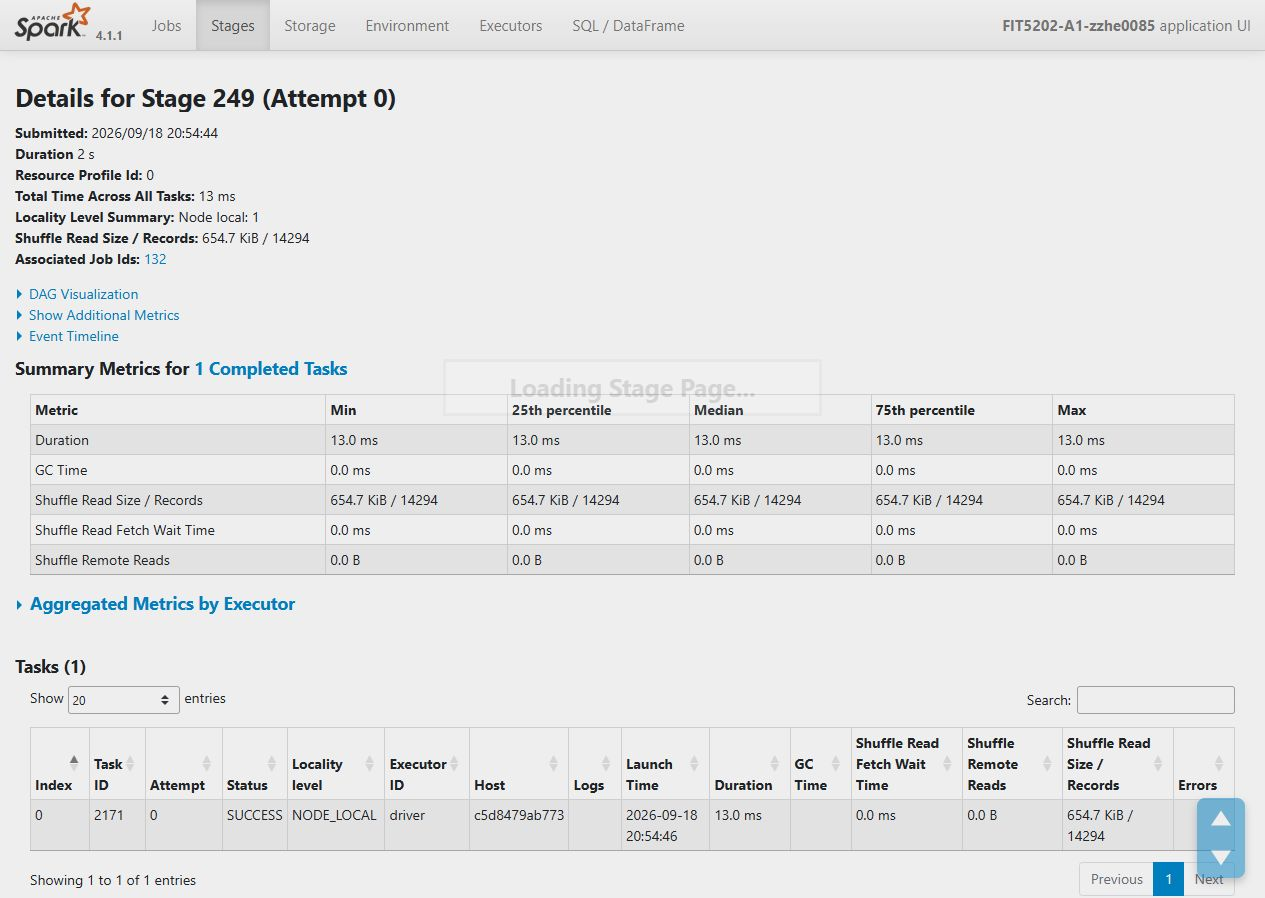

Part 3.2: latest baseline aggregation shuffle-read evidence.

##### 3.3 Evaluate one optimisation  
Implement one optimisation based on the evidence and reasoning presented in Section 3.2. Briefly state what you changed and why you expect it to improve execution.  
Before executing it, set: sc.setJobDescription(f"A1-P3-3-Optimised-{student_auth_code}")  
Then:  
1. Run the baseline and revised queries under the same conditions;
2. Confirm that the optimised query produces exactly the same result as the baseline
3. Record the execution time and collect the corresponding Spark UI evidence.
4. Decide whether the optimisation should be retained, justify your decision.
5. A technically reasonable improvement and evidence-based evaluation are required for full marks.


In [ ]:
def optimized_report():
    # One structural optimization: derive benchmark from area aggregates by a window.
    month_window = Window.partitionBy('Month')
    grouped = (area_peak_counts()
        .withColumn('MonthlyViolationCount', F.sum('ViolationCount').over(month_window))
        .withColumn('MonthlyKnownCount', F.sum('KnownViolationCount').over(month_window))
        .withColumn('MonthlyViolationBenchmark',
                    percentage(F.col('MonthlyViolationCount'), F.col('MonthlyKnownCount'))))
    return finish_report(grouped)

optimized_query, optimized_rows, optimized_seconds, optimized_evidence = timed_report(
    optimized_report, f'A1-P3-3-Optimised-{student_auth_code}', 'P3_optimized')
optimized_query.explain(mode='formatted')
baseline_result = spark.createDataFrame(baseline_rows, baseline_query.schema)
optimized_result = spark.createDataFrame(optimized_rows, optimized_query.schema)
baseline_minus_optimized = baseline_result.exceptAll(optimized_result).count()
optimized_minus_baseline = optimized_result.exceptAll(baseline_result).count()
print('Baseline minus optimized:', baseline_minus_optimized,
      'Optimized minus baseline:', optimized_minus_baseline)
assert baseline_minus_optimized == optimized_minus_baseline == 0
optimized_metrics = labelled_stage_metrics(optimized_evidence, f'A1-P3-3-Optimised-{student_auth_code}')
display(optimized_metrics)


In [ ]:
# Both variants already ran; these alternating measured repetitions reduce order bias.
# Same full prepared disk cache, four cores, AQE, shuffle config, action and inputs.
benchmark_runs = []
for repetition in range(1, 4):
    order = [('Baseline', dataframe_report), ('Optimised', optimized_report)]
    if repetition % 2 == 0:
        order.reverse()
    for variant, factory in order:
        prefix = 'A1-P3-2-Baseline' if variant == 'Baseline' else 'A1-P3-3-Optimised'
        query, rows, seconds, _ = timed_report(factory,
            f'{prefix}-{student_auth_code}-repeat{repetition}', f'P3_{variant.lower()}_repeat{repetition}')
        assert rows == baseline_rows, 'Benchmark result changed'
        benchmark_runs.append((repetition, variant, seconds, len(rows)))
benchmark_pdf = pd.DataFrame(benchmark_runs, columns=['Repetition', 'Variant', 'Seconds', 'ResultRows'])
display(benchmark_pdf)
medians = benchmark_pdf.groupby('Variant').Seconds.median()
speedup = medians['Baseline'] / medians['Optimised']
print('Median baseline seconds:', medians['Baseline'])
print('Median optimized seconds:', medians['Optimised'])
print('Median speedup:', speedup)
decision = ('retain this optimization for the measured recurring-report workload'
            if speedup > 1 else 'do not retain this optimization on performance grounds in this environment')
display(Markdown(
    f"The median of three alternating measured runs was **{medians['Baseline']:.3f} s** "
    f"for the baseline and **{medians['Optimised']:.3f} s** for the revised query "
    f"(speedup **{speedup:.3f}×**). I would **{decision}**. "
    "Both directions of exceptAll returned zero mismatches. The change is limited "
    "to deriving the benchmark from per-area aggregates; input persistence and Spark "
    "settings are unchanged. Both variants use a fully materialised shared prepared "
    "input and the same complete collect action, with no cached final report. "
    "These timings exclude one-time data preparation and represent a recurring report, "
    "not cold CSV ingestion. Three local runs do not establish a universal speedup; "
    "OS file caching, JVM compilation and other desktop activity remain limitations."))
benchmark_pdf.to_csv(OUTPUT_DIR / 'benchmark_runs.csv', index=False)
(OUTPUT_DIR / 'run_summary.json').write_text(json.dumps({
    'auth_code': student_auth_code, 'spark_version': spark.version,
    'raw_counts': raw_counts, 'validation': validation_values,
    'traffic_summary': traffic_summary_values,
    'negative_duration': negative_values, 'monthly_result_rows': len(df_rows),
    'monthly_result_months': len({row.Month for row in df_rows}),
    'df_sql_mismatches': [df_minus_sql, sql_minus_df],
    'optimization_mismatches': [baseline_minus_optimized, optimized_minus_baseline],
    'baseline_seconds': baseline_seconds, 'optimized_seconds': optimized_seconds,
    'median_speedup': speedup}, indent=2))


#### Optimised Spark UI evidence

Run: 18 September 2026, Query 53, Jobs 136-140. The source aggregation is Stage 257; Stage 259 reads its 654.7 KiB shuffle output. The full collect action took 3.024 s. These screenshots show the first measured optimized run; the three repeated measurements are reported separately above.

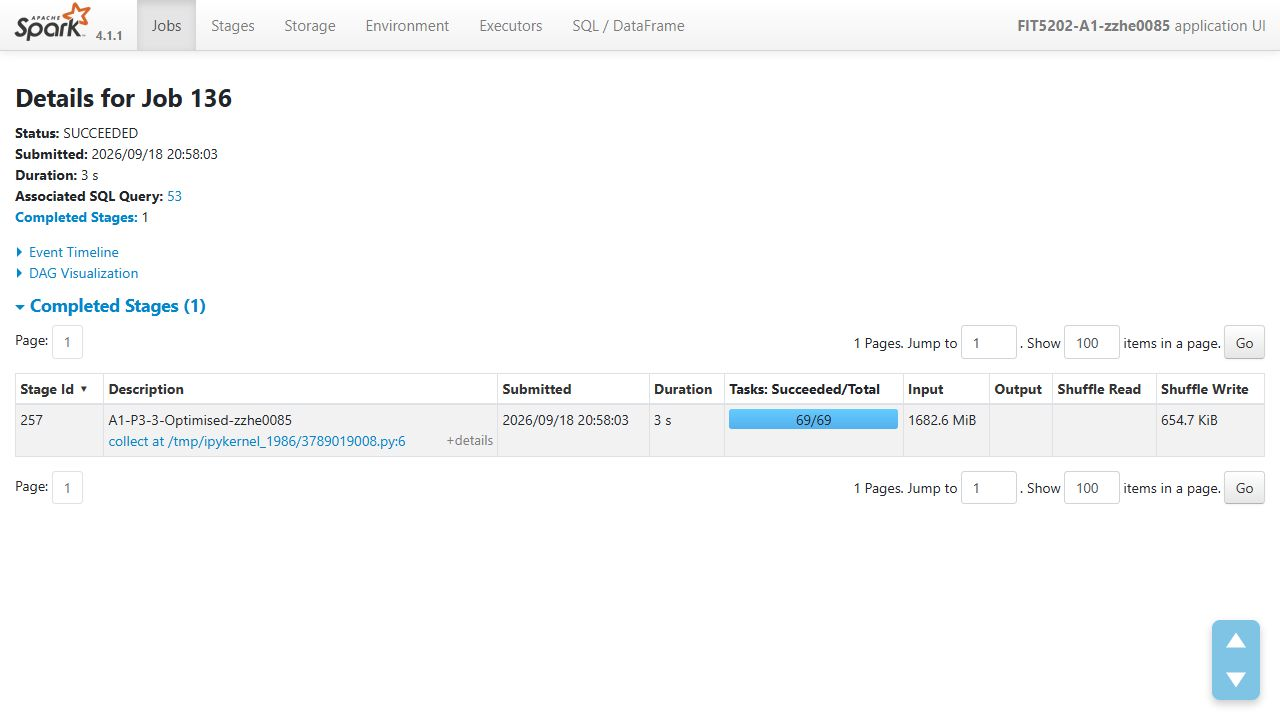

Part 3.3: latest optimized job with the required auth-code label.

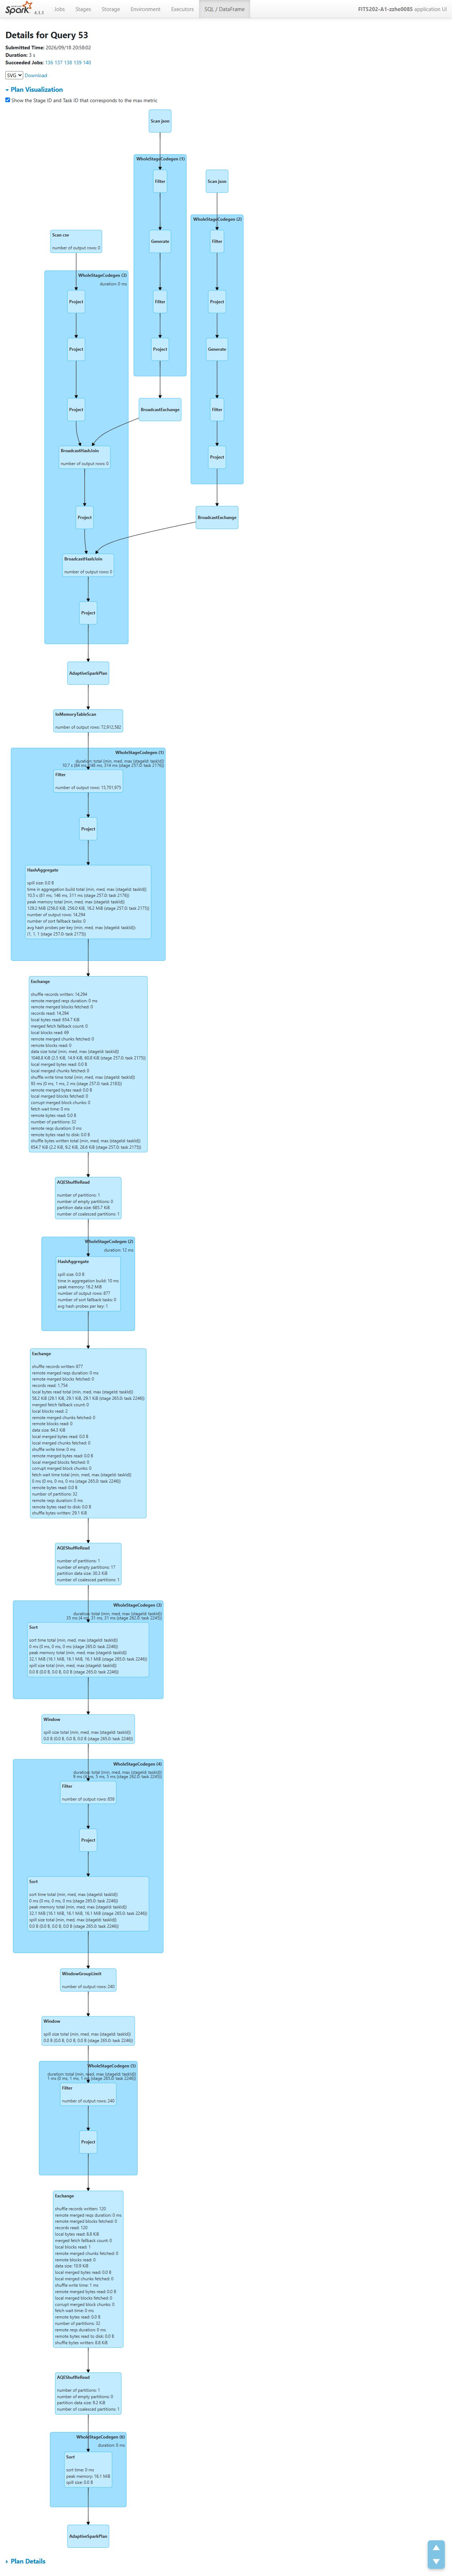

Part 3.3: actual optimized SQL graph; benchmark derived by a window over area aggregates.

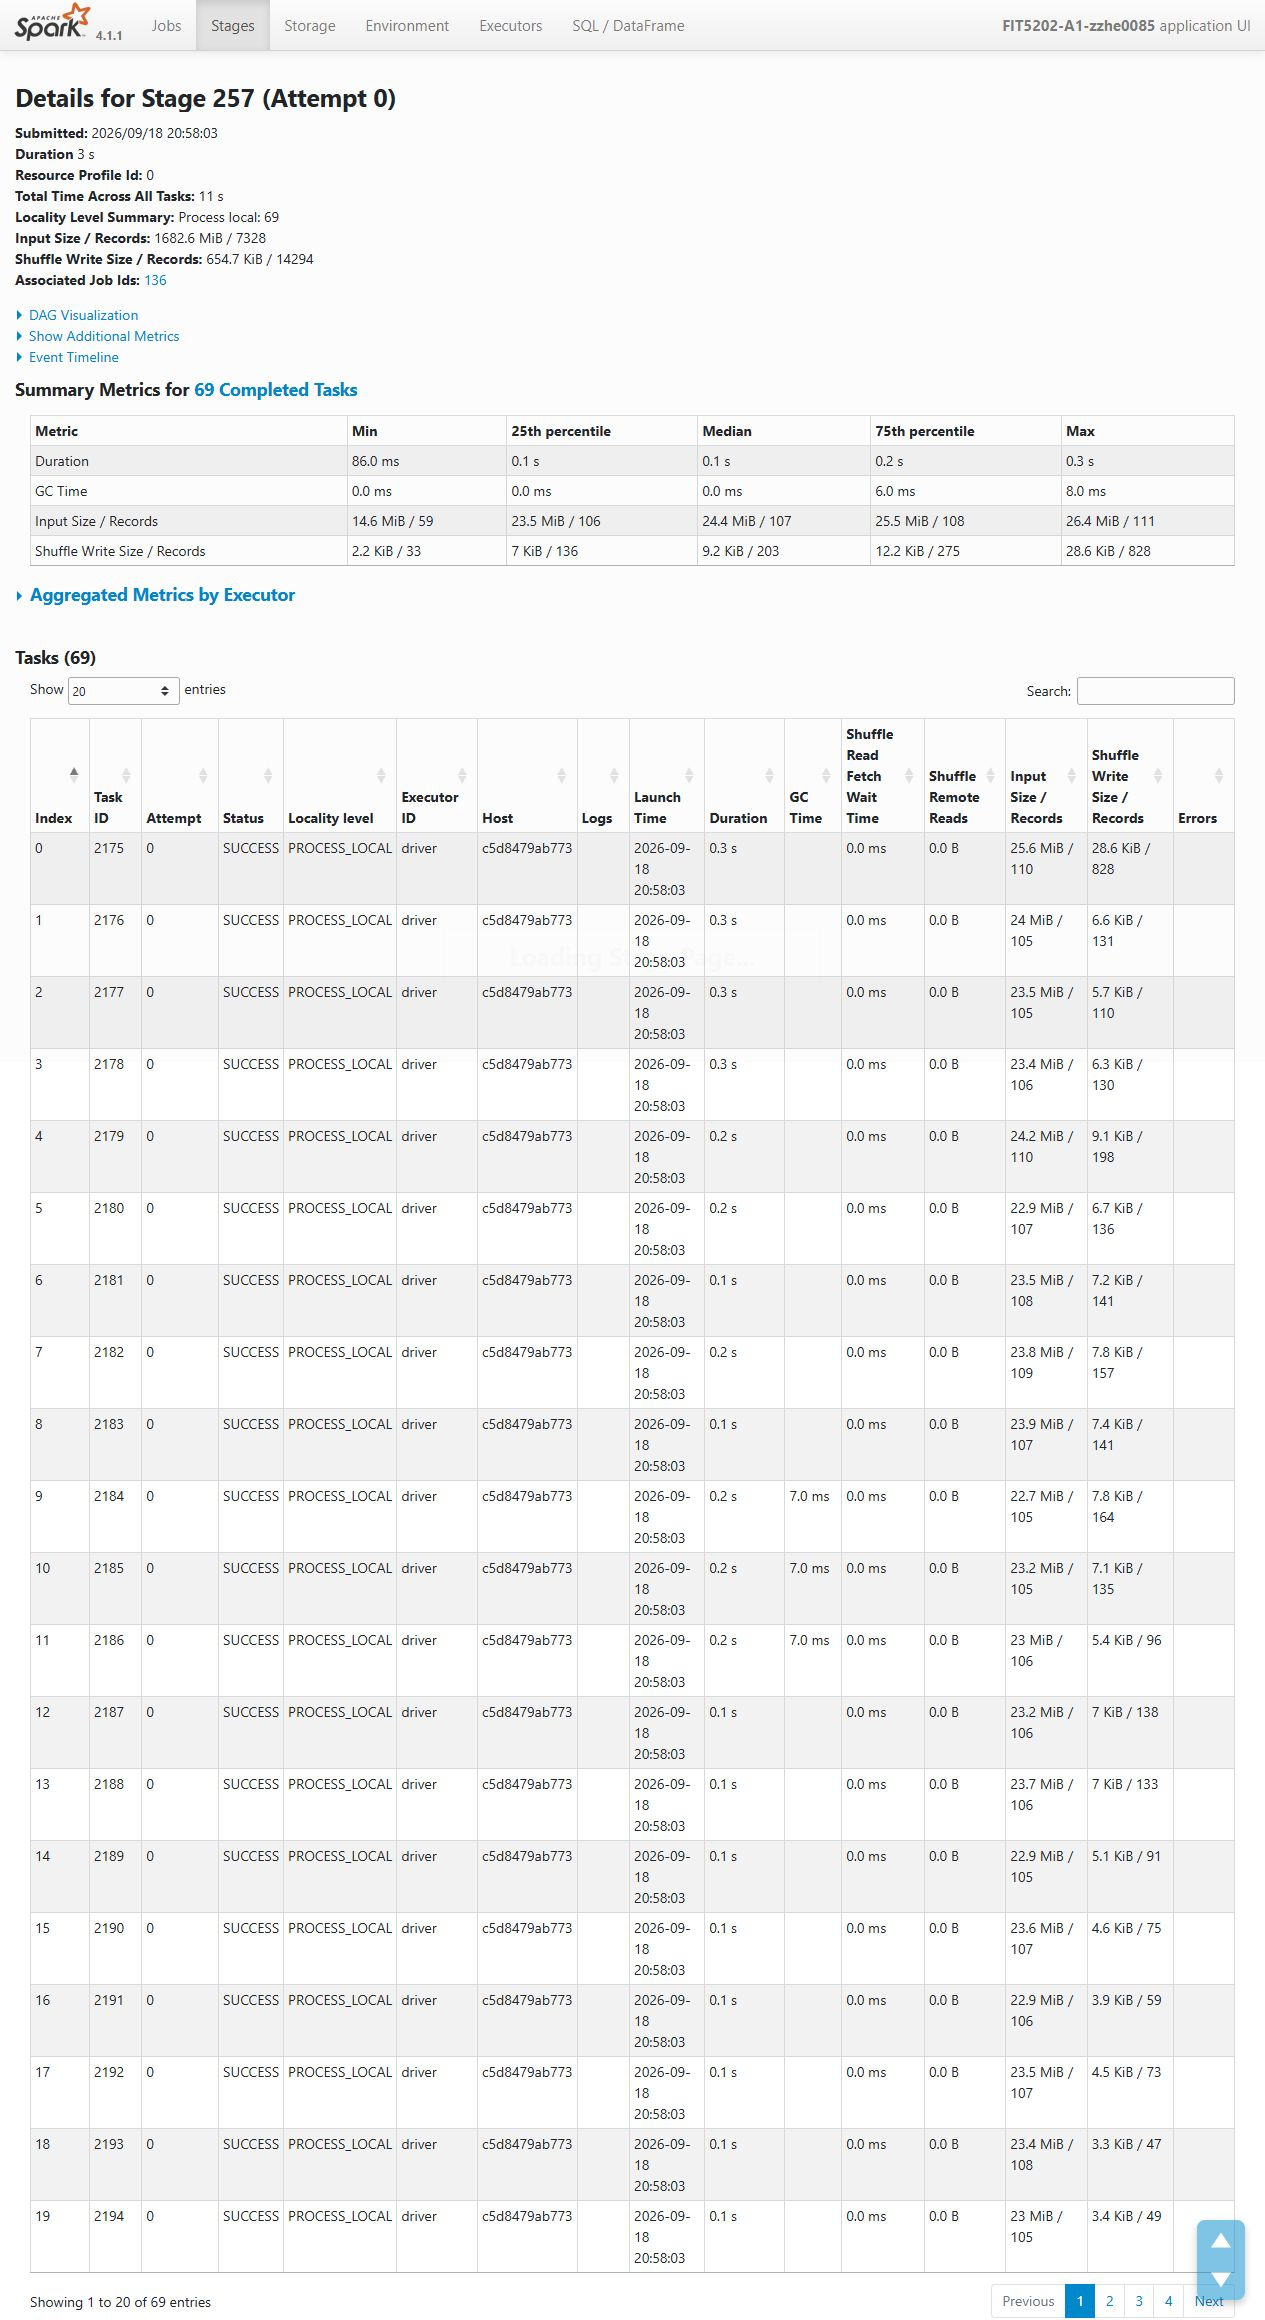

Part 3.3: source aggregation metrics under the same input and Spark settings.

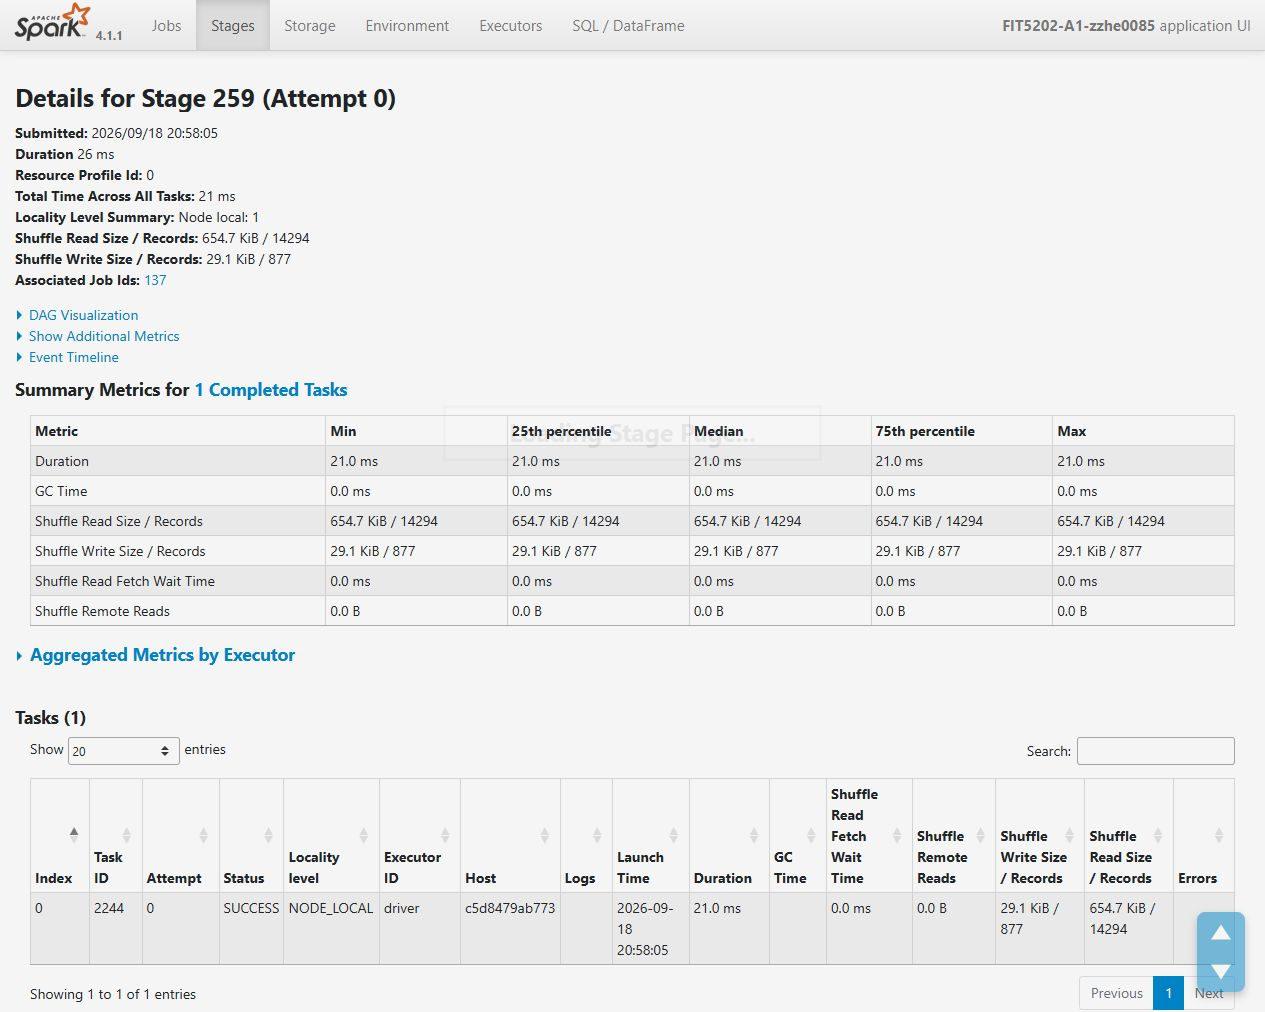

Part 3.3: shuffle read/write metrics for the compact area-month aggregation.

### Part 4: Interview preparation
The live interview is completed by the student, not by this notebook. Be prepared to
run a section and explain: explicit schemas and tolerant parsing; valid-session versus
valid-duration populations; active-day denominators; broadcast versus shuffle joins;
the traffic block encoding assumption; weighted monthly benchmarks; why eligibility
precedes ranking; multiset equality; Spark lazy evaluation; and the measured
optimization's trade-offs. Review the course announcement and book the interview.

### References
- FIT5202 Assignment 1, 2026 S2, supplied specification and A1 template.
- Apache Spark, [Performance Tuning (4.0.2)](https://spark.apache.org/docs/4.0.2/sql-performance-tuning.html).
- Apache Spark, [Configuration (4.0.0)](https://spark.apache.org/docs/4.0.0/configuration.html).
- Apache Spark, [try_to_timestamp](https://spark.apache.org/docs/4.0.3/api/python/reference/pyspark.sql/api/pyspark.sql.functions.try_to_timestamp.html).

Version-specific behaviour is checked in the actual course image (version printed
in Section 1.1). Dates in source data have no explicit UTC offset; interpreting
ambiguous daylight-saving times remains a source-data limitation.

### Additional semantic verification
These small expected-result checks run after the full-data measurements. They test edge cases absent from or difficult to isolate in the supplied dataset, and do not replace the full-data results.

In [ ]:
"""Small, explicit expected-result checks, executed after full-data measurements."""
# This source is also appended to the notebook, with its real execution output.
sc.setJobDescription(f'A1-SemanticChecks-{student_auth_code}')

# Verify the specified inclusivity/exclusivity at peak boundaries and weekends.
boundary_rows = [
    (2, 6, 59, False), (2, 7, 0, True), (2, 8, 59, True),
    (2, 9, 0, False), (6, 15, 59, False), (6, 16, 0, True),
    (6, 18, 29, True), (6, 18, 30, False), (7, 8, 0, False),
    (1, 17, 0, False),
]
boundary_frame = spark.createDataFrame(
    boundary_rows, ['DayOfWeek', 'ArrivalHour', 'ArrivalMinute', 'ExpectedPeak'])
boundary_result = boundary_frame.withColumn('ActualPeak', peak_condition)
assert boundary_result.filter(F.col('ActualPeak') != F.col('ExpectedPeak')).count() == 0
boundary_result.show(truncate=False)

block_frame = spark.createDataFrame([
    ('2018-01-01 00:00:00', '2018-01-01 00:00:00'),
    ('2018-01-01 00:09:59', '2018-01-01 00:00:00'),
    ('2018-01-01 00:10:00', '2018-01-01 00:10:00'),
    ('2018-01-01 23:59:59', '2018-01-01 23:50:00'),
], ['ArrivalText', 'ExpectedBlock'])
block_frame = (block_frame.withColumn('ArrivalTime', F.to_timestamp('ArrivalText'))
    .withColumn('ActualBlock', F.date_format(
        F.window('ArrivalTime', '10 minutes').getField('start'), 'yyyy-MM-dd HH:mm:ss')))
assert block_frame.filter(F.col('ActualBlock') != F.col('ExpectedBlock')).count() == 0
block_frame.show(truncate=False)

# Expected monthly outcomes deliberately distinguish pooled rates from averages of
# area percentages, unknown from false, strict eligibility, and deterministic top 5.
fixture_rows = []


def add_fixture(month, area, true_count, false_count, unknown_count=0):
    for flag in [True]*true_count + [False]*false_count + [None]*unknown_count:
        fixture_rows.append((month, area, f'Area {area}', True, flag))


add_fixture('2018-01', 1, 1, 1, 1)
add_fixture('2018-01', 2, 9, 1)
add_fixture('2018-01', 3, 0, 1)
add_fixture('2018-02', 1, 1, 1)
add_fixture('2018-02', 2, 1, 1)  # Equal to benchmark: neither qualifies.
for area in range(1, 7):
    add_fixture('2018-03', area, 9, 1)
add_fixture('2018-03', 99, 0, 100)
fixture_rows.append(('2018-01', 3, 'Area 3', False, True))  # Must be excluded.

real_monthly_input = monthly_input
try:
    monthly_input = spark.createDataFrame(fixture_rows, real_monthly_input.schema)
    monthly_input.createOrReplaceTempView('monthly_input')
    fixture_df = dataframe_report().collect()
    fixture_sql = spark.sql(MONTHLY_SQL).collect()
    fixture_optimized = optimized_report().collect()
    assert fixture_df == fixture_sql == fixture_optimized
    assert [(row.Month, row.AreaId, row.MonthlyRank) for row in fixture_df] == [
        ('2018-01', 2, 1), ('2018-03', 1, 1), ('2018-03', 2, 2),
        ('2018-03', 3, 3), ('2018-03', 4, 4), ('2018-03', 5, 5)]
    january = fixture_df[0]
    assert january.PeakSessionCount == 10 and january.ViolationCount == 9
    assert abs(january.ViolationRate - 90) < 1e-10
    assert abs(january.MonthlyViolationBenchmark - 1000/13) < 1e-10
    print('PASS: peak boundaries, weekend exclusion, half-open time blocks, pooled benchmark,')
    print('unknown violation denominator, strict eligibility, deterministic top five, and all three query variants.')
finally:
    monthly_input = real_monthly_input
    monthly_input.createOrReplaceTempView('monthly_input')
    sc.setJobDescription(None)
